# Imports

In [1]:

from jax import config
config.update("jax_enable_x64", True)


import pulseseq
from pulseseq.sequencing.waveform import AnalogPulse, Apodization, Shape, DigitalPulse, DigitalType
from qcontrol.snv120.distribution import SnV120Distribution, SnVConstants
import qcontrol.snv120.hamiltonian_jqt as qh_jqt
from qcontrol.snv120.jqt_ext import sesolve_components, mesolve_components
import qcontrol.snv120.parameters as params
from qcontrol.snv120.parameters import HyperfineNeighbor
import qcontrol.snv120.pulseseq_interconnect
from qcontrol.snv120.pulseseq_interconnect import stack_waveforms, make_analog_pulse_time_array, synthesize_analog_pulse
import numpy as np
import jax.numpy as jnp
from matplotlib import pyplot as plt
from scipy.constants import c
from typing import NamedTuple, Any, Dict, Mapping
from abc import ABC, abstractmethod
from datetime import datetime
import jax
import jaxquantum as jqt
from diffrax import SaveAt



from typing import Callable
import time

# SnV Distribution

In [2]:
N=10000
constants = SnVConstants(
    B_target = jnp.asarray([0.0, 0.0, 1.4/0.85]),                   # (x, y, z) magnetic field relative to the dipole axis, units of GHz
    laser_frequency = params.GAMMA_FREQ - 2.5,
    target_dipole_operator = jnp.asarray([0, 0, 1]), # (x,y,z) vector in the local dipole frame
    diamond_lattice_100_orientation = jnp.asarray([0, 0]), # Best estimate of (theta, phi) for the diamond lattice [100] axis in the lab frame
    diamond_lattice_011_orientation = jnp.asarray([jnp.pi/2, 0]), # Best estimate of (theta, phi) for the diamond lattice [011] axis in the lab frame
    nominal_magnet_axes = jnp.asarray([[0, 0, 1], [0, 1, 0], [1, 0, 0]]), # (3, 3) nominal vector magnet axes unit vectors in the lab frame. 
    sampling_rate = 6.144, # awg sampling rate, units of GHz
)
def get_basic_distribution(N):
    return SnV120Distribution(
        weights=jnp.ones((N))/N, # N
        constants=constants,

        magnet_unit_magnitude=jnp.ones((N, 3)), # (N, 3) error in vector magnet axes magnitude
        magnet_axes_rotations=jnp.zeros((N, 3, 3)), # (N, 3, 3) rotational vectors (magnitude, theta, phi) applied to the vector magnet axes in the lab frame. 
        dipole_crystal_axis_idx = jnp.arange((N), dtype=jnp.int32)%4, # N, index of the crystal axis to use for the dipole moment
        
        strain_params=jnp.array([jnp.zeros(N), 10*jnp.ones((N)), 0.03*jnp.ones((N)), 0.03*jnp.ones((N)), 0.03*jnp.ones((N))]),

        # Hyperfine neighbor parameters
        hyperfine_neighbor_idx = HyperfineNeighbor.C13_FIRST_CLASS_0*jnp.ones((N), dtype=jnp.int32), # N, index of the hyperfine neighbor to use for the hyperfine interaction

        # Excited state lifetime
        excited_state_lifetime = jnp.ones((N))*6,

        # Collection efficiency parameters
        debye_waller_factor = jnp.ones((N))*0.6,
        quantum_efficiency = jnp.ones((N))*0.8,
        optical_transmission = jnp.ones((N))*0.01,
        dark_count_rate = jnp.ones((N))*0.001,

        # Resonant pump coupling
        resonant_pump_coupling_rate = 0.03*jnp.ones((N)),
        resonant_pump_polarization = jnp.zeros((N)),
        resonant_pump_pdl = jnp.ones((N)),
        resonant_pump_phase = jnp.zeros((N)),
        # transmission_to_diamond = jnp.ones((N, 2)), # (N, 2), Transmission from the edge coupler to the diamond for the TE and TM modes
        mode_field_orientation = jnp.broadcast_to(jnp.asarray([[0.0, 0.0],[0.5 * jnp.pi, 0.5 * jnp.pi],]), (N,2,2)), # (N, 2, 2), Electric field orientation for the TE and TM modes in the crystal frame
        transmission_out_diamond = jnp.ones((N, 2)), # (N, 2), Transmission from the diamond to the edge coupler for the TE and TM modes
        reflection_from_pic = 0*jnp.ones((N, 2)), # (N, 2), Reflection of the resonant pump from the PIC to the APD for the TE and TM modes

        eom_vpi_ratio = 0.6*jnp.ones((N)),
        eom_vpi_bandwidth = 1.5*jnp.ones((N)),

        # Transmission line dynamic B field
        mw_B_orientation = jnp.tile(jnp.asarray([np.pi/2, 0]), (N, 1)), # (N, 2), transmission line B field orientation (theta, phi) in the crystal frame
        mw_B_magnitude = 0.5*jnp.ones((N)),   # N, in units of Tesla
        mw_B_bandwidth = 1.5*jnp.ones((N)),    # N, in units of GHz

        # Drift and diffusion
        spectral_diffusion_rate = jnp.ones((N)),  # N, in units of Hz/sqrt(s)
        polarization_drift_rate = jnp.ones((N)),  # N, in units of rads/sqrt(s)
        resonant_pump_coupling_drift_rate = jnp.ones((N)),  # N, in units of rads/sqrt(s)
    )

dist = get_basic_distribution(N)

## Test 1

In [3]:
print(jqt.identity(3).dtype)
print(jqt.basis(3,0).dtype)

complex128
complex128


In [4]:
# Longitudinal Emitter
idx = 0
b_field_settings = dist.get_B_settings(idx=idx)
print("B field settings:", np.array2string(np.asarray(b_field_settings), formatter={'float_kind':lambda x: f"{x:.2f}"}), "Tesla")
B_cartesian_lab = dist.get_B_cartesian(idx=idx, frame='lab')
B_cartesian_dipole = dist.get_B_cartesian(idx=idx, frame='dipole')
print(f"Lab frame Cartesian B field: {np.array2string(np.asarray(B_cartesian_lab), formatter={'float_kind':lambda x: f"{x:.2f}"})} Tesla")
print(f"Dipole frame Cartesian B field: {np.array2string(np.asarray(B_cartesian_dipole), formatter={'float_kind':lambda x: f"{x:.2f}"})} Tesla")
print(f"Dipole B theta: {dist.get_B_theta(idx=idx, frame='dipole')*180/jnp.pi:.2f} degrees")
print(f"Dipole B phi: {dist.get_B_phi(idx=idx, frame='dipole')*180/jnp.pi:.2f} degrees")
print(f"Dipole B magnitude: {dist.get_dipole_B_GHz(idx=idx)} GHz")
print(f"ODMR Freqs: {dist.get_emr_freqs(idx=idx)} GHz")

pump_eta = dist.get_resonant_pump_eta(idx=idx)
pump_eta_norm = pump_eta/jnp.linalg.norm(pump_eta)
print(f"Resonant Pump Eta: {pump_eta}")
print(f"Pump eta orientation: {pump_eta_norm}")

B field settings: [0.03 0.00 0.05] Tesla
Lab frame Cartesian B field: [0.05 0.00 0.03] Tesla
Dipole frame Cartesian B field: [0.00 0.00 0.06] Tesla
Dipole B theta: 0.00 degrees
Dipole B phi: 0.00 degrees
Dipole B magnitude: 1.6470588235294117 GHz
ODMR Freqs: [1.92388118 1.92388118] GHz
Resonant Pump Eta: [-1.62976385e-02-6.79869978e-19j -1.73472348e-18-1.17756934e-18j
  2.30483414e-02+9.61481343e-19j]
Pump eta orientation: [-5.77350269e-01-2.40846620e-17j -6.14532632e-17-4.17158583e-17j
  8.16496581e-01+3.40608557e-17j]


In [5]:
# Transverse Emitter
idx = 1
b_field_settings = dist.get_B_settings(idx=idx)
print("B field settings:", np.array2string(np.asarray(b_field_settings), formatter={'float_kind':lambda x: f"{x:.2f}"}), "Tesla")
B_cartesian_lab = dist.get_B_cartesian(idx=idx, frame='lab')
B_cartesian_dipole = dist.get_B_cartesian(idx=idx, frame='dipole')
print(f"Lab frame Cartesian B field: {np.array2string(np.asarray(B_cartesian_lab), formatter={'float_kind':lambda x: f"{x:.2f}"})} Tesla")
print(f"Dipole frame Cartesian B field: {np.array2string(np.asarray(B_cartesian_dipole), formatter={'float_kind':lambda x: f"{x:.2f}"})} Tesla")
print(f"Dipole B theta: {dist.get_B_theta(idx=idx, frame='dipole')*180/jnp.pi:.2f} degrees")
print(f"Dipole B phi: {dist.get_B_phi(idx=idx, frame='dipole')*180/jnp.pi:.2f} degrees")
print(f"Dipole B magnitude: {dist.get_dipole_B_GHz(idx=idx)} GHz")
print(f"ODMR Freqs: {dist.get_emr_freqs(idx=idx)} GHz")
pump_eta = dist._get_resonant_pump_eta_batch(idx=jnp.asarray([idx]))
pump_eta_norm = pump_eta/jnp.linalg.norm(pump_eta)
print(f"Resonant Pump Eta: {pump_eta_norm}")
print(f"Nuclear ODMR Freqs: {dist.get_nmr_freqs(idx=idx)} GHz")
H0, Hb = dist.get_ground_hamiltonian(idx=1, included_states=(0,1,2,3))
print(H0)
print(Hb)

B field settings: [0.03 0.05 0.00] Tesla
Lab frame Cartesian B field: [0.00 0.05 0.03] Tesla
Dipole frame Cartesian B field: [-0.00 0.00 0.06] Tesla
Dipole B theta: 0.00 degrees
Dipole B phi: 180.00 degrees
Dipole B magnitude: 1.6470588235294117 GHz
ODMR Freqs: [1.92373374 1.92373374] GHz
Resonant Pump Eta: [[ 0.57735027-4.03117709e-17j  0.        -1.53253752e-16j
  -0.81649658+5.70094531e-17j]]
Nuclear ODMR Freqs: [0. 0.] GHz
Quantum array: dims = ((4,), (4,)), bdims = (), shape = (4, 4), type = oper, impl = dense
Qarray data =
[[-0.96186687+0.j  0.        +0.j  0.        +0.j  0.        +0.j]
 [ 0.        +0.j -0.96186687+0.j  0.        +0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j  0.96186687+0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j  0.        +0.j  0.96186687+0.j]]
Quantum array: dims = ((4,), (4,)), bdims = (), shape = (4, 4), type = oper, impl = dense
Qarray data =
[[ 0.        +0.j  0.        +0.j -0.23860965+0.j  0.        +0.j]
 [ 0.        +0.j  0.    

In [6]:

H0, Hb = dist.get_ground_hamiltonian(idx=0, included_states=(0, 1, 2, 3))
print(H0)
print(Hb)

Quantum array: dims = ((4,), (4,)), bdims = (), shape = (4, 4), type = oper, impl = dense
Qarray data =
[[-0.96194059+0.j  0.        +0.j  0.        +0.j  0.        +0.j]
 [ 0.        +0.j -0.96194059+0.j  0.        +0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j  0.96194059+0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j  0.        +0.j  0.96194059+0.j]]
Quantum array: dims = ((4,), (4,)), bdims = (), shape = (4, 4), type = oper, impl = dense
Qarray data =
[[0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]]


In [7]:
ple_freqs = dist.get_ple_freqs(idx=0)
print(ple_freqs)
print(ple_freqs[2]-ple_freqs[1])

[484210.85536835 484210.85536835 484211.19818165 484211.19818165]
0.3428132941480726


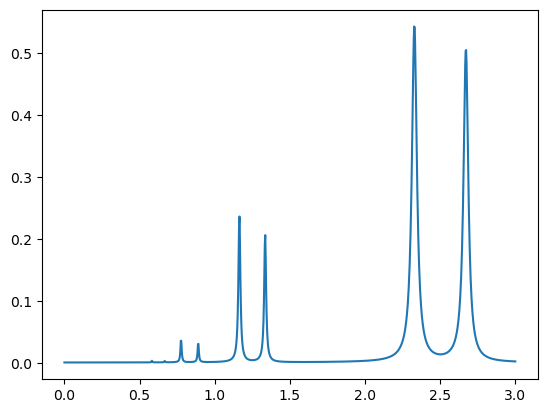

In [8]:
f, df = 1.5, 1.5
eom_freqs = jnp.linspace(f-df, f+df, 1000)
idx = np.array([0])
rates, branching_ratios = dist.scattering_rate(idx=idx, eom_frequency=eom_freqs, max_bessel_order=4)
rates = rates.sum(axis=(-3,-2,-1))  # Sum over the distribution
plt.plot(eom_freqs, rates[0, :]*dist.excited_state_lifetime[0])

(5000, 1000)


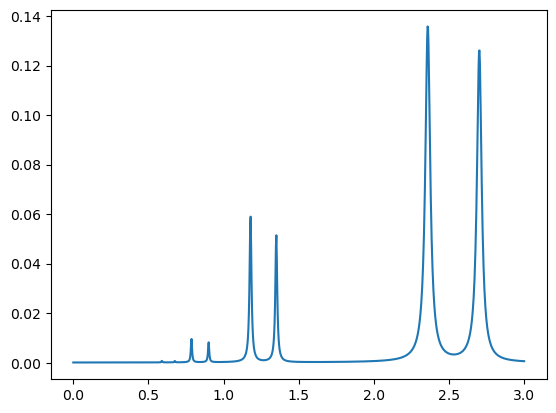

In [ ]:
f, df = 1.5, 1.5
eom_freqs = jnp.linspace(f-df, f+df, 1000)
idx = jnp.arange(N//2, N)
rates, branching_ratios = dist.scattering_rate(idx=idx, eom_frequency=eom_freqs, max_bessel_order=4, sum_counts=True)
print(rates.shape)
plt.plot(eom_freqs, rates[0, :]*dist.excited_state_lifetime[0])

# Test Ground State Simulation

(6144,)
(6144,)


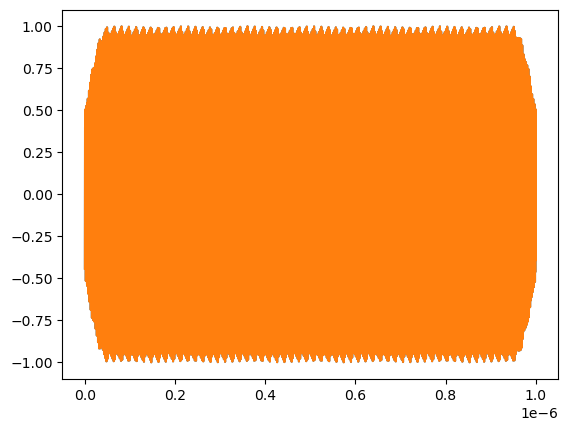

RMS error: 1.1005034190100882e-13


In [ ]:
# -------------------------------------------------------------------------
# Example
# -------------------------------------------------------------------------
idx = 0
pulse = AnalogPulse(
    length=1e-6,
    apodization=Apodization.COSINE,
    apodization_length=1e-7,
    padding_length=0,
    shift=0,
    amplitude=1,
    frequency=dist.get_emr_freqs(idx=idx)[0]*1e9,
    frequency_chirp=0,
    shape=Shape.TRIANGLE,
    S21_correct=True,
    w_3db=2e9,
    phase_offset=np.nan,
    name="",
)

# A zero-duration pulse cannot generate its own useful time grid, so supply
# the desired observation window explicitly.
tau = make_analog_pulse_time_array(pulse, 1/6.144e9, at_time=pulse.length/2)

waveform, envelope, returned_tau = synthesize_analog_pulse(
    pulse=pulse,
    tau=tau,
    at_time=pulse.length/2,
    all_info=True,
    dphase=0.0,
)
true_waveform, true_envelope, true_tau = pulse.synthesize(tau, at_time=pulse.length/2, dphase=0.0, all_info=True)
print(waveform.shape)
print(true_waveform.shape)
plt.plot(tau, waveform)
plt.plot(true_tau, true_waveform)
plt.show()
print("RMS error:", np.sqrt(np.mean((waveform - true_waveform)**2)))
assert np.all(np.isclose(waveform, true_waveform))
assert np.all(np.isclose(envelope, true_envelope))
assert np.all(np.isclose(tau, true_tau))

stacked_pulses = stack_waveforms([pulse, pulse])
# Use argument order, pass as positional arguments
stacked_waveforms, stacked_envelope, stacked_tau = jax.vmap(
    synthesize_analog_pulse,
    in_axes=(0, None, None, None, None)
)(
    stacked_pulses, tau, pulse.length/2, True, 0.0
)

assert np.all(np.isclose(stacked_waveforms[0], true_waveform))
assert np.all(np.isclose(stacked_envelope[0], true_envelope))
assert np.all(np.isclose(stacked_tau[0], true_tau))
assert np.all(np.isclose(stacked_waveforms[1], true_waveform))
assert np.all(np.isclose(stacked_envelope[1], true_envelope))
assert np.all(np.isclose(stacked_tau[1], true_tau))

[1.92380743 1.92380743]
Quantum array: dims = ((4,), (4,)), bdims = (), shape = (4, 4), type = oper, impl = dense
Qarray data =
[[-0.96190371-1.22686083e-14j  0.        +0.00000000e+00j
   0.        +0.00000000e+00j  0.        +0.00000000e+00j]
 [ 0.        +0.00000000e+00j -0.96190371-1.22686083e-14j
   0.        +0.00000000e+00j  0.        +0.00000000e+00j]
 [ 0.        +0.00000000e+00j  0.        +0.00000000e+00j
   0.96190371+1.22686083e-14j  0.        +0.00000000e+00j]
 [ 0.        +0.00000000e+00j  0.        +0.00000000e+00j
   0.        +0.00000000e+00j  0.96190371+1.22686083e-14j]]
Quantum array: dims = ((4,), (4,)), bdims = (), shape = (4, 4), type = oper, impl = dense
Qarray data =
[[ 0.        +0.j  0.        +0.j -0.00602238+0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j  0.        +0.j -0.00602238+0.j]
 [-0.00602238+0.j  0.        +0.j  0.        +0.j  0.        +0.j]
 [ 0.        +0.j -0.00602238+0.j  0.        +0.j  0.        +0.j]]


100% |██████████| [00:01<00:00, 60.18%/s]


(614, 4, 1)


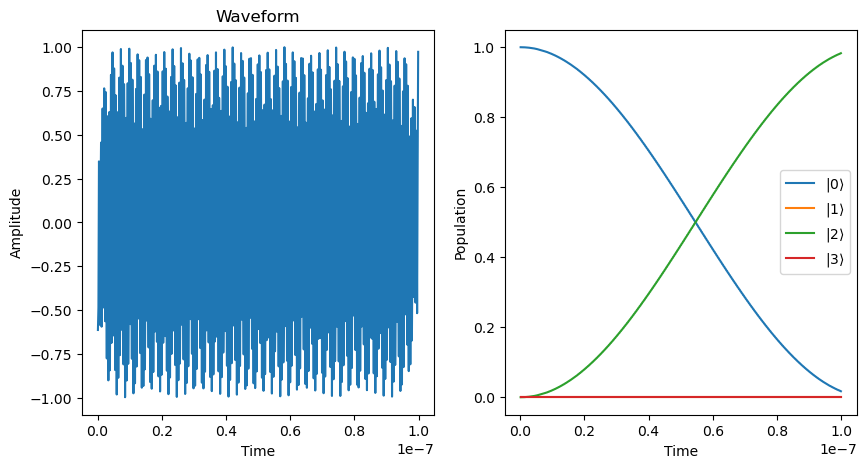

Quantum array: dims = ((4,), (1,)), bdims = (), shape = (4, 1), type = ket, impl = dense
Qarray data =
[[0.12881008-0.02224876j]
 [0.        +0.j        ]
 [0.91727714+0.37617669j]
 [0.        +0.j        ]]


In [ ]:
idx = 0
pulse = AnalogPulse(
    length=100e-9,
    apodization=Apodization.COSINE,
    apodization_length=10e-9,
    padding_length=0,
    shift=0,
    amplitude=1,
    frequency=dist.get_emr_freqs(idx=idx)[0]*1e9,
    frequency_chirp=0,
    shape=Shape.TRIANGLE,
    S21_correct=True,
    w_3db=2e9,
    phase_offset=np.nan,
    name="",
)

sampling_rate = 6.144e9

H0, Hb = dist.get_ground_hamiltonian(idx=0, included_states=(0, 1, 2, 3))
H0_rads_s = 2*jnp.pi * H0 * 1e9
Hb_rads_s = 2*jnp.pi * Hb * 1e9
print(dist.get_emr_freqs(idx=idx))
print(H0)
print(Hb)
def H_t_func(t, args=None):
    return Hb_rads_s * synthesize_analog_pulse(pulse, jnp.asarray([t-1/sampling_rate, t, t+1/sampling_rate]), at_time=pulse.length/2, dphase=0.0, all_info=True)[0][1] + H0_rads_s
psi0 = jqt.basis(4, 0)

tau = make_analog_pulse_time_array(pulse, 1/sampling_rate, at_time=pulse.length/2)


waveform, envelope, returned_tau = synthesize_analog_pulse(
    pulse=pulse,
    tau=tau,
    at_time=pulse.length/2,
    all_info=True,
    dphase=0.0,
)

save_times = tau[::]
states = jqt.sesolve(H_t_func, psi0, tau, saveat_tlist=save_times)
print(states.shape)

# Population operators |i><i|
projectors = [
    jqt.basis(4, i).to_dm()
    for i in range(4)
]

# <P_i> = Tr[P_i rho(t)]
populations = jnp.stack(
    [
        jnp.real(jqt.overlap(projector, states))
        for projector in projectors
    ],
    axis=0,
)
fig, axs = plt.subplots(1,2, figsize=(10, 5))
axs[0].plot(tau, waveform)
axs[0].set_title("Waveform")
axs[0].set_xlabel("Time")
axs[0].set_ylabel("Amplitude")

for i in range(4):
    axs[1].plot(
        np.asarray(save_times),
        np.asarray(populations[i]),
        label=fr"$|{i}\rangle$",
    )

axs[1].set_xlabel("Time")
axs[1].set_ylabel("Population")
axs[1].legend()
plt.show()
print(states[-1])

100% |██████████| [00:05<00:00, 17.26%/s]


(62, 1, 4, 1)
(62, 1)


/home/floresh2/.conda/envs/zm/lib/python3.12/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/floresh2/.conda/envs/zm/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


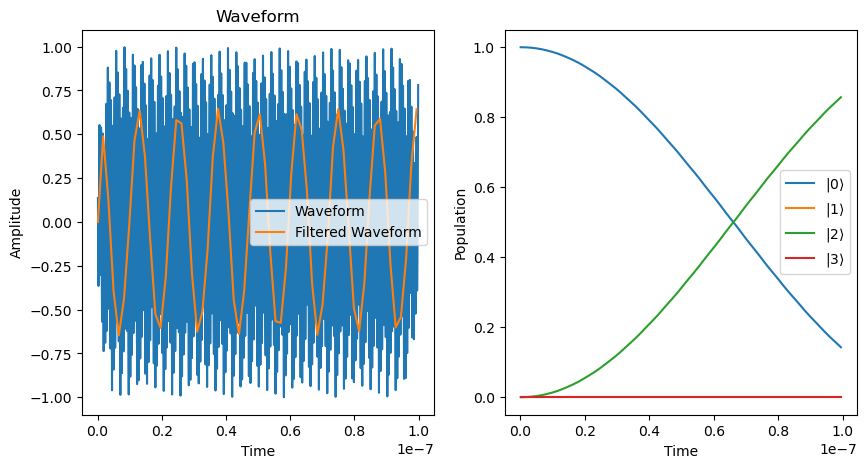

Quantum array: dims = ((4,), (1,)), bdims = (1,), shape = (1, 4, 1), type = ket, impl = dense
Qarray data =
[[[-0.37789483-0.00415993j]
  [ 0.        +0.j        ]
  [ 0.20113934-0.90372487j]
  [ 0.        +0.j        ]]]


In [ ]:
idx = 0
pulse = AnalogPulse(
    length=100e-9,
    apodization=Apodization.COSINE,
    apodization_length=10e-9,
    padding_length=0,
    shift=0,
    amplitude=1,
    frequency=dist.get_emr_freqs(idx=idx)[0]*1e9,
    frequency_chirp=0,
    shape=Shape.TRIANGLE,
    S21_correct=True,
    w_3db=2*jnp.pi*2e9,
    phase_offset=np.nan,
    name="",
)
H0, Hb = dist.get_ground_hamiltonian(idx=0, included_states=(0, 1, 2, 3))
H0_rads_s = 2*jnp.pi * H0 * 1e9
Hb_rads_s = 2*jnp.pi * Hb * 1e9
sampling_rate = dist.constants.sampling_rate*1e9

def H_b_drive(t, args=None):
    return synthesize_analog_pulse(pulse, jnp.asarray([t-1/sampling_rate, t, t+1/sampling_rate]), at_time=pulse.length/2, dphase=0.0, all_info=True)[0][1]

def lowpass_filter(omega_c):
    """H(s) = omega_c / (s + omega_c)."""
    omega_c = jnp.asarray(omega_c)

    def filter_fn(t, z, u):
        del t
        dz_dt = omega_c * (u - z)
        output = z
        return dz_dt, output

    return filter_fn

hamiltonians = [H0_rads_s, Hb_rads_s]
coefficients = [1.0, H_b_drive]
omega_c = 2*jnp.pi*dist.mw_B_bandwidth[idx]*1e9
filters = [None, lowpass_filter(omega_c)]
filter_y0s = [None, jnp.zeros(1, dtype=jnp.complex128)]

psi0 = jqt.basis(4, 0)

tau = make_analog_pulse_time_array(pulse, 1/sampling_rate, at_time=pulse.length/2)

save_times = tau[::10]
states, filter_states, = sesolve_components(hamiltonians, coefficients, psi0, tau, saveat_tlist=save_times, filters=filters, filter_y0s=filter_y0s, return_filter_states=True, solver_options=jqt.SolverOptions.create(progress_meter=True, solver="Dopri5"))
print(states.shape)
print(filter_states[1].shape)

# Population operators |i><i|
projectors = [
    jqt.basis(4, i).to_dm()
    for i in range(4)
]

# <P_i> = Tr[P_i rho(t)]
populations = jnp.stack(
    [
        jnp.real(jqt.overlap(projector, states))
        for projector in projectors
    ],
    axis=0,
)


waveform, envelope, returned_tau = synthesize_analog_pulse(
    pulse=pulse,
    tau=tau,
    at_time=pulse.length/2,
    all_info=True,
    dphase=0.0,
)
fig, axs = plt.subplots(1,2, figsize=(10, 5))
axs[0].plot(tau, waveform, label="Waveform")
axs[0].plot(save_times, filter_states[1], label="Filtered Waveform")
axs[0].set_title("Waveform")
axs[0].set_xlabel("Time")
axs[0].set_ylabel("Amplitude")
axs[0].legend()

for i in range(4):
    axs[1].plot(
        np.asarray(save_times),
        np.asarray(populations[i]),
        label=fr"$|{i}\rangle$",
    )

axs[1].set_xlabel("Time")
axs[1].set_ylabel("Population")
axs[1].legend()
plt.show()
print(states[-1])

In [ ]:
def _prepare_indices(dist, idx):
    """Normalize public scalar/array/None indices for the jitted batch cores."""
    scalar_idx = idx is not None and jnp.asarray(idx).ndim == 0

    if idx is None:
        idx_array = jnp.arange(
            dist.weights.shape[0],
            dtype=jnp.int32,
        )
    else:
        idx_array = jnp.atleast_1d(
            jnp.asarray(idx, dtype=jnp.int32)
        )

    return idx_array, scalar_idx

/home/floresh2/.conda/envs/zm/lib/python3.12/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/floresh2/.conda/envs/zm/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


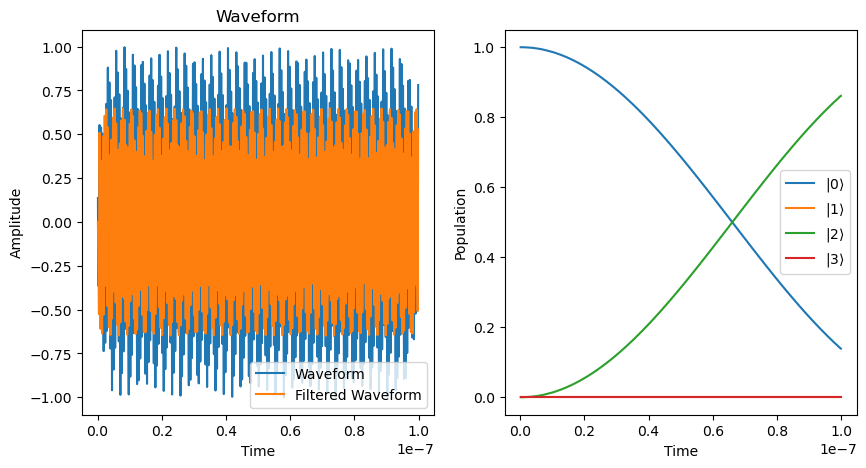

Quantum array: dims = ((4,), (1,)), bdims = (), shape = (4, 1), type = ket, impl = dense
Qarray data =
[[ 0.36668373-0.06624764j]
 [ 0.        +0.j        ]
 [-0.36957435+0.85113818j]
 [ 0.        +0.j        ]]


In [ ]:

idx = 0

pulse = AnalogPulse(
    length=100e-9,
    apodization=Apodization.COSINE,
    apodization_length=10e-9,
    padding_length=0,
    shift=0,
    amplitude=1,
    frequency=dist.get_emr_freqs(idx=idx)[0] * 1e9,
    frequency_chirp=0,
    shape=Shape.TRIANGLE,
    S21_correct=True,
    w_3db=2 * jnp.pi * 2e9,
    phase_offset=np.nan,
    name="",
)

states, filter_states, populations = dist.drive_mw_hamiltonian(
    idx=idx,
    pulse=pulse,
    included_states=(0, 1, 2, 3),
    saveat_final_only=False,
)

tau = make_analog_pulse_time_array(pulse, 1/dist.constants.sampling_rate/1e9, at_time=pulse.length/2)
waveform, envelope, returned_tau = synthesize_analog_pulse(
    pulse=pulse,
    tau=tau,
    at_time=pulse.length / 2,
    all_info=True,
    dphase=0.0,
)
fig, axs = plt.subplots(1,2, figsize=(10, 5))
axs[0].plot(returned_tau, waveform, label="Waveform")
axs[0].plot(returned_tau, filter_states[1], label="Filtered Waveform")
axs[0].set_title("Waveform")
axs[0].set_xlabel("Time")
axs[0].set_ylabel("Amplitude")
axs[0].legend()

for i in range(4):
    axs[1].plot(
        np.asarray(returned_tau),
        np.asarray(populations[i]),
        label=fr"$|{i}\rangle$",
    )

axs[1].set_xlabel("Time")
axs[1].set_ylabel("Population")
axs[1].legend()
plt.show()
print(states[-1])

## Verify low pass filtering accuracy

/home/floresh2/.conda/envs/zm/lib/python3.12/site-packages/equinox/_jit.py:55: UserWarning: Complex dtype support in Diffrax is a work in progress and may not yet produce correct results. Consider splitting your computation into real and imaginary parts instead.
  out = fun(*args, **kwargs)


Cutoff frequency:      1.500000e+09 Hz
Filter time constant:  1.061033e-10 s
Raw-drive peak:        1.000000e+00
Filtered-drive peak:   6.509235e-01
Maximum abs error:     6.185363e-03
Relative RMS error:    1.351999e-03


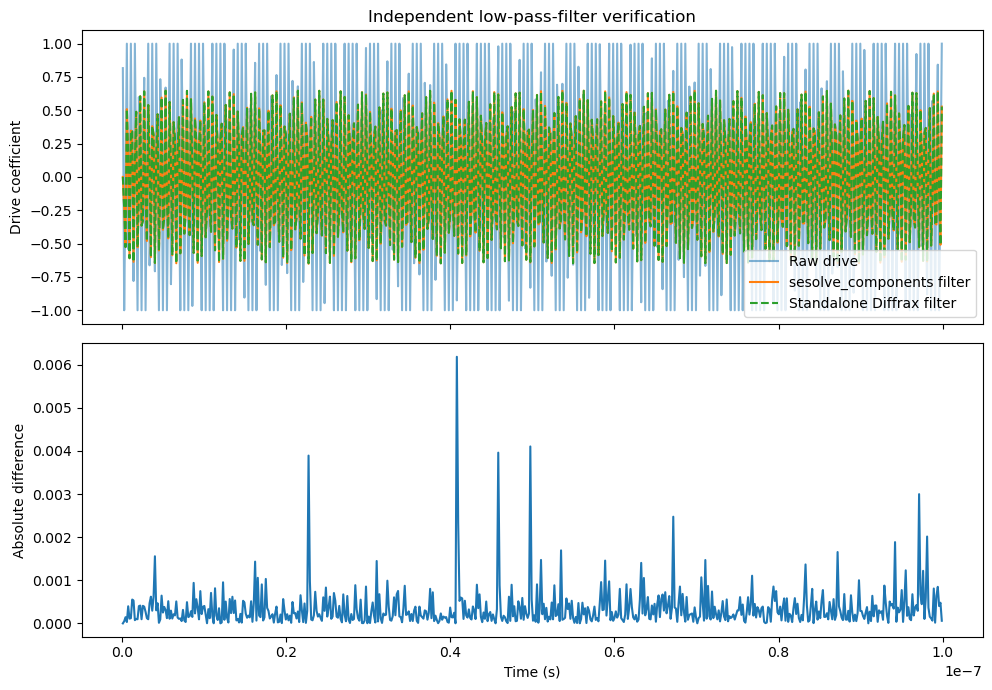

In [ ]:
import diffrax as dfx
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
H0, Hb = dist.get_ground_hamiltonian(idx=0, included_states=(0, 1, 2, 3))
H0_rads_s = 2*jnp.pi * H0 * 1e9
Hb_rads_s = 2*jnp.pi * Hb * 1e9
sampling_rate = dist.constants.sampling_rate*1e9

def H_b_drive(t, args=None):
    return synthesize_analog_pulse(pulse, jnp.asarray([t-1/sampling_rate, t, t+1/sampling_rate]), at_time=pulse.length/2, dphase=0.0, all_info=True)[0][1]

def lowpass_filter(omega_c):
    """H(s) = omega_c / (s + omega_c)."""
    omega_c = jnp.asarray(omega_c)

    def filter_fn(t, z, u):
        del t
        dz_dt = omega_c * (u - z)
        output = z
        return dz_dt, output

    return filter_fn

hamiltonians = [H0_rads_s, Hb_rads_s]
coefficients = [1.0, H_b_drive]
omega_c = 2*jnp.pi*dist.mw_B_bandwidth[idx]*1e9
filters = [None, lowpass_filter(omega_c)]
filter_y0s = [None, jnp.zeros(1, dtype=jnp.complex128)]

psi0 = jqt.basis(4, 0)

tau = make_analog_pulse_time_array(pulse, 1/sampling_rate, at_time=pulse.length/2)

save_times = tau[::]
# ---------------------------------------------------------------------------
# Standalone Diffrax verification of the low-pass-filter state
# ---------------------------------------------------------------------------

save_times_check = jnp.asarray(save_times)

# Use exactly the same initial state as the coupled quantum/filter solve.
# A scalar state is preferable, but this also works with your current shape-(1,)
# state, i.e. jnp.zeros(1, dtype=jnp.complex128).
filter_y0_check = jnp.asarray(filter_y0s[1])


def standalone_lowpass_rhs(t, z, args):
    """Single-pole low-pass filter with no quantum-system evolution."""
    del args

    # This is the exact same raw coefficient entering sesolve_components.
    raw_drive = jnp.asarray(H_b_drive(t), dtype=z.dtype)
    cutoff = jnp.asarray(omega_c, dtype=z.dtype)

    return cutoff * (raw_drive - z)


standalone_solution = dfx.diffeqsolve(
    terms=dfx.ODETerm(standalone_lowpass_rhs),
    solver=dfx.Tsit5(),
    t0=save_times_check[0],
    t1=save_times_check[-1],

    # Match JAXQuantum's initial-step choice.
    dt0=save_times_check[1] - save_times_check[0],

    y0=filter_y0_check,

    # Save only at the comparison times; no dense solution is constructed.
    saveat=dfx.SaveAt(ts=save_times_check),

    stepsize_controller=dfx.PIDController(
        rtol=1e-7,
        atol=1e-9,
    ),
    max_steps=100_000,
    progress_meter=dfx.NoProgressMeter(),
)

# Ensure execution is complete before timing, printing, or plotting.
standalone_filtered = jax.block_until_ready(standalone_solution.ys)

# filter_states is aligned with the Hamiltonian list:
# filter_states[0] is None and filter_states[1] is the filtered Hb coefficient.
coupled_filtered = jax.block_until_ready(
    jnp.asarray(filter_states[1])
)

# Remove a trailing singleton state dimension, if present.
# For example, both (N,) and (N, 1) become directly comparable.
standalone_filtered_1d = jnp.squeeze(standalone_filtered)
coupled_filtered_1d = jnp.squeeze(coupled_filtered)

if standalone_filtered_1d.shape != coupled_filtered_1d.shape:
    raise ValueError(
        "Filter-output shapes do not match:\n"
        f"  standalone Diffrax: {standalone_filtered_1d.shape}\n"
        f"  sesolve_components: {coupled_filtered_1d.shape}"
    )

# Sample the unfiltered drive only for plotting.
raw_drive_values = jax.vmap(H_b_drive)(save_times_check)
raw_drive_values = jax.block_until_ready(raw_drive_values)

# ---------------------------------------------------------------------------
# Numerical comparison
# ---------------------------------------------------------------------------

error = coupled_filtered_1d - standalone_filtered_1d

max_abs_error = jnp.max(jnp.abs(error))
rms_error = jnp.sqrt(jnp.mean(jnp.abs(error) ** 2))
reference_rms = jnp.sqrt(
    jnp.mean(jnp.abs(standalone_filtered_1d) ** 2)
)
relative_rms_error = rms_error / jnp.maximum(
    reference_rms,
    jnp.finfo(reference_rms.dtype).eps,
)

print(
    "Cutoff frequency:      "
    f"{float(omega_c / (2.0 * jnp.pi)):.6e} Hz"
)
print(
    "Filter time constant:  "
    f"{float(1.0 / omega_c):.6e} s"
)
print(
    "Raw-drive peak:        "
    f"{float(jnp.max(jnp.abs(raw_drive_values))):.6e}"
)
print(
    "Filtered-drive peak:   "
    f"{float(jnp.max(jnp.abs(coupled_filtered_1d))):.6e}"
)
print(
    "Maximum abs error:     "
    f"{float(max_abs_error):.6e}"
)
print(
    "Relative RMS error:    "
    f"{float(relative_rms_error):.6e}"
)

# ---------------------------------------------------------------------------
# Plot the independently evolved filter and comparison error
# ---------------------------------------------------------------------------

times_np = np.asarray(save_times_check)
raw_np = np.real_if_close(np.asarray(raw_drive_values))
coupled_np = np.real_if_close(np.asarray(coupled_filtered_1d))
standalone_np = np.real_if_close(np.asarray(standalone_filtered_1d))
error_np = np.asarray(jnp.abs(error))

fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 7),
    sharex=True,
)

axes[0].plot(
    times_np,
    raw_np,
    label="Raw drive",
    alpha=0.55,
)
axes[0].plot(
    times_np,
    coupled_np,
    label="sesolve_components filter",
)
axes[0].plot(
    times_np,
    standalone_np,
    "--",
    label="Standalone Diffrax filter",
)

axes[0].set_title("Independent low-pass-filter verification")
axes[0].set_ylabel("Drive coefficient")
axes[0].legend()

axes[1].plot(
    times_np,
    error_np,
)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Absolute difference")

plt.tight_layout()
plt.show()

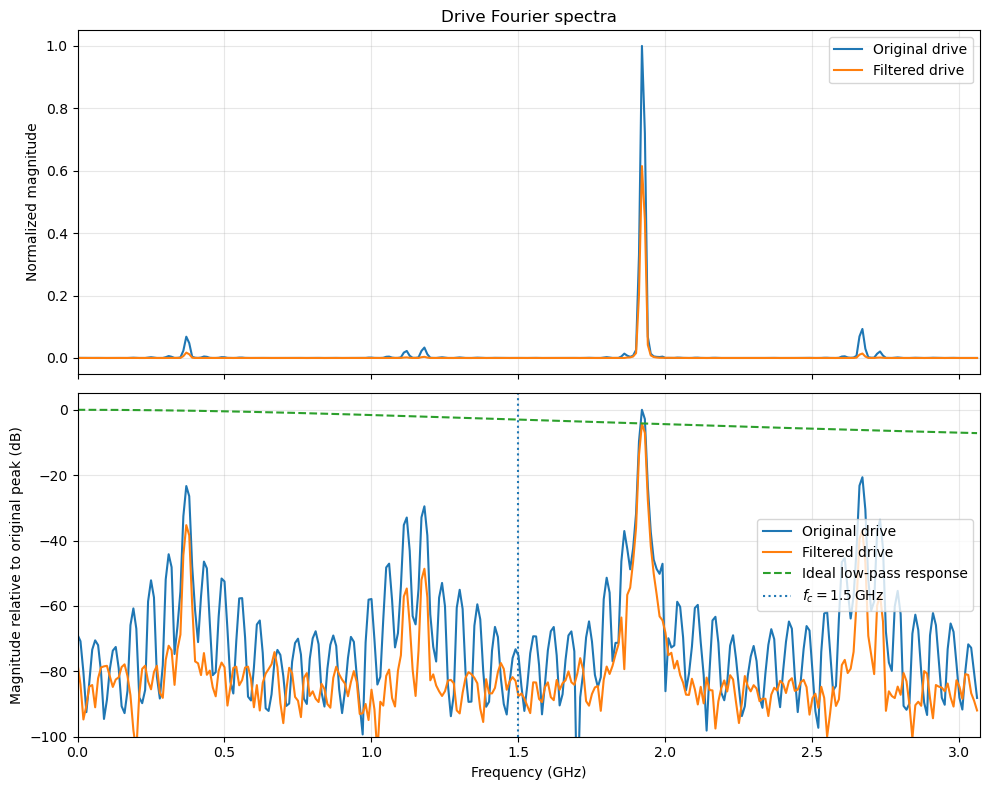

Sample rate:       6.144000 GHz
Nyquist frequency: 3.072000 GHz
Filter cutoff:     1.500000 GHz


In [ ]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------------
# Fourier spectra of the original and low-pass-filtered drive
# ---------------------------------------------------------------------------

times = np.asarray(save_times, dtype=np.float64)

# Evaluate the original drive at the same uniformly spaced times used for
# saving the filtered state.
original_signal = np.asarray(
    jax.vmap(H_b_drive)(jnp.asarray(save_times))
).squeeze()

# For the low-pass filter used here, the filter state is also its output.
filtered_signal = np.asarray(filter_states[1]).squeeze()

if original_signal.shape != filtered_signal.shape:
    raise ValueError(
        "Original and filtered signals have different shapes:\n"
        f"  original: {original_signal.shape}\n"
        f"  filtered: {filtered_signal.shape}"
    )

if times.ndim != 1 or times.size != original_signal.size:
    raise ValueError(
        "save_times must be one-dimensional and have one entry per signal sample."
    )

# An FFT requires uniformly spaced sample times.
time_steps = np.diff(times)
dt = np.mean(time_steps)

if not np.allclose(time_steps, dt, rtol=1e-6, atol=1e-15):
    raise ValueError(
        "save_times are not uniformly spaced, so a standard FFT is not valid."
    )

sample_rate = 1.0 / dt
nyquist_frequency = 0.5 * sample_rate

# A Hann window reduces spectral leakage caused by truncating the finite pulse.
window = np.hanning(original_signal.size)

# Correct approximately for the coherent amplitude loss caused by the window.
coherent_gain = np.mean(window)

original_fft = np.fft.fft(original_signal * window)
filtered_fft = np.fft.fft(filtered_signal * window)

frequencies = np.fft.fftfreq(original_signal.size, d=dt)

# Keep the nonnegative-frequency half of the spectrum.
positive = frequencies >= 0.0
frequencies_positive = frequencies[positive]

original_magnitude = (
    np.abs(original_fft[positive])
    #/ (original_signal.size * coherent_gain)
)
filtered_magnitude = (
    np.abs(filtered_fft[positive])
    #/ (filtered_signal.size * coherent_gain)
)

# Normalize both spectra to the same reference: the original-signal peak.
reference = max(
    np.max(original_magnitude),
    np.finfo(np.float64).tiny,
)

original_normalized = original_magnitude / reference
filtered_normalized = filtered_magnitude / reference

# Convert to decibels while avoiding log10(0).
minimum_linear_amplitude = 1e-12
original_db = 20.0 * np.log10(
    np.maximum(original_normalized, minimum_linear_amplitude)
)
filtered_db = 20.0 * np.log10(
    np.maximum(filtered_normalized, minimum_linear_amplitude)
)

# Optional theoretical magnitude response of the single-pole low-pass filter:
#
#     |H(f)| = 1 / sqrt(1 + (f / f_c)^2)
#
# This uses the same omega_c supplied to lowpass_filter.
cutoff_hz = float(omega_c / (2.0 * jnp.pi))

theoretical_lowpass = 1.0 / np.sqrt(
    1.0 + (frequencies_positive / cutoff_hz) ** 2
)
theoretical_lowpass_db = 20.0 * np.log10(
    np.maximum(theoretical_lowpass, minimum_linear_amplitude)
)

# ---------------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 8),
    sharex=True,
)

frequency_ghz = frequencies_positive / 1e9

axes[0].plot(
    frequency_ghz,
    original_normalized,
    label="Original drive",
)
axes[0].plot(
    frequency_ghz,
    filtered_normalized,
    label="Filtered drive",
)
axes[0].set_ylabel("Normalized magnitude")
axes[0].set_title("Drive Fourier spectra")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    frequency_ghz,
    original_db,
    label="Original drive",
)
axes[1].plot(
    frequency_ghz,
    filtered_db,
    label="Filtered drive",
)
axes[1].plot(
    frequency_ghz,
    theoretical_lowpass_db,
    "--",
    label="Ideal low-pass response",
)
axes[1].axvline(
    cutoff_hz / 1e9,
    linestyle=":",
    label=fr"$f_c={cutoff_hz / 1e9:.3g}\,\mathrm{{GHz}}$",
)

axes[1].set_xlabel("Frequency (GHz)")
axes[1].set_ylabel("Magnitude relative to original peak (dB)")
axes[1].set_ylim(-100.0, 5.0)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Display only the physically represented positive-frequency range.
axes[1].set_xlim(0.0, nyquist_frequency / 1e9)

plt.tight_layout()
plt.show()

print(f"Sample rate:       {sample_rate / 1e9:.6f} GHz")
print(f"Nyquist frequency: {nyquist_frequency / 1e9:.6f} GHz")
print(f"Filter cutoff:     {cutoff_hz / 1e9:.6f} GHz")

## Benchmark Accuracy vs Tolerance

atol: 1e-09, rtol: 1.0000000000000001e-07


100% |██████████| [00:10<00:00,  9.34%/s]
100% |██████████| [00:10<00:00,  9.33%/s]


atol: 9.999999999999999e-09, rtol: 9.999999999999978e-07


100% |██████████| [00:06<00:00, 15.56%/s]
100% |██████████| [00:06<00:00, 15.34%/s]


atol: 1.0000000000000001e-07, rtol: 9.999999999999999e-06


...

100% |██████████| [00:01<00:00, 65.08%/s]
100% |██████████| [00:01<00:00, 65.88%/s]


atol: 9.999999999999999e-06, rtol: 0.001


100% |██████████| [00:00<00:00, 116.05%/s]
100% |██████████| [00:00<00:00, 118.63%/s]


atol: 9.999999999999999e-05, rtol: 0.01


100% |██████████| [00:00<00:00, 213.88%/s]
100% |██████████| [00:00<00:00, 205.12%/s]


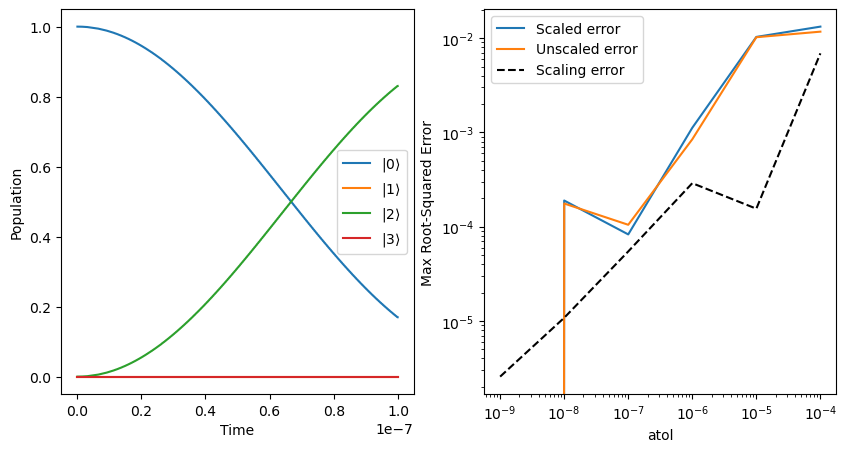

In [ ]:

idx = 0

pulse = AnalogPulse(
    length=100e-9,
    apodization=Apodization.COSINE,
    apodization_length=10e-9,
    padding_length=0,
    shift=0,
    amplitude=1,
    frequency=dist.get_emr_freqs(idx=idx)[0] * 1e9 + 1e6,
    frequency_chirp=0,
    shape=Shape.TRIANGLE,
    S21_correct=True,
    w_3db=2 * jnp.pi * 2e9,
    phase_offset=np.nan,
    name="",
)


pulse_unscaled = AnalogPulse(
    length=100,
    apodization=Apodization.COSINE,
    apodization_length=10,
    padding_length=0,
    shift=0,
    amplitude=1,
    frequency=dist.get_emr_freqs(idx=idx)[0] + 0.001,
    frequency_chirp=0,
    shape=Shape.TRIANGLE,
    S21_correct=True,
    w_3db=2 * jnp.pi *2,
    phase_offset=np.nan,
    name="",
)

sweep_length = 6
atols = jnp.logspace(-9, -4, sweep_length)
rtols = jnp.logspace(-7, -2, sweep_length)
populations_sweep = []
populations_sweep_unscaled = []
max_rs_error_sweep = []
max_rs_error_sweep_unscaled = []
for i, (atol,rtol) in enumerate(zip(atols, rtols)):
    print(f"atol: {atol}, rtol: {rtol}")
    solver_options_args = (True, "Dopri5", int(1e5), float(rtol), float(atol))
    states, filter_states, populations = dist.drive_mw_hamiltonian(
        idx=idx,
        pulse=pulse,
        included_states=(0, 1, 2, 3),
        saveat_final_only=False,
        solver_options_args=solver_options_args,
    )
    states_unscaled, filter_states_unscaled, populations_unscaled = dist.drive_mw_hamiltonian(
        idx=idx,
        pulse=pulse_unscaled,
        included_states=(0, 1, 2, 3),
        saveat_final_only=False,
        solver_options_args=solver_options_args,
        scale=1
    )
    populations_sweep.append(populations)
    populations_sweep_unscaled.append(populations_unscaled)
    max_rs_error_sweep.append(jnp.sqrt(jnp.max(jnp.square(populations[:, -1] - populations_sweep[0][:, -1]))))
    max_rs_error_sweep_unscaled.append(jnp.sqrt(jnp.max(jnp.square(populations_unscaled[:, -1] - populations_sweep_unscaled[0][:, -1]))))


tau = make_analog_pulse_time_array(pulse, 1/dist.constants.sampling_rate/1e9, at_time=pulse.length/2)
waveform, envelope, returned_tau = synthesize_analog_pulse(
    pulse=pulse,
    tau=tau,
    at_time=pulse.length / 2,
    all_info=True,
    dphase=0.0,
)

fig, axs = plt.subplots(1,2, figsize=(10, 5))

for i in range(4):
    axs[0].plot(
        np.asarray(returned_tau),
        np.asarray(populations_sweep[0][i]),
        label=fr"$|{i}\rangle$",
    )

axs[0].set_xlabel("Time")
axs[0].set_ylabel("Population")
axs[0].legend()

axs[1].plot(atols, max_rs_error_sweep, label="Scaled error")
axs[1].plot(atols, max_rs_error_sweep_unscaled, label="Unscaled error")
scaling_error = [jnp.sqrt(jnp.max(jnp.square(populations_sweep_unscaled[i][:, -1] - populations_sweep[i][:, -1]))) for i in range(len(populations_sweep))]
axs[1].plot(atols, scaling_error, label='Scaling error', color='black', linestyle='--')
axs[1].set_xlabel("atol")
axs[1].set_ylabel("Max Root-Squared Error")
axs[1].set_xscale("log")
axs[1].set_yscale("log")
axs[1].legend()
plt.show()

## Benchmark Time


Benchmarking N = 10
  Mean:   1381.420 ms
  Median: 1381.792 ms
  Min:    1378.879 ms
  Max:    1384.388 ms

Benchmarking N = 31
  Mean:   1379.263 ms
  Median: 1379.310 ms
  Min:    1378.381 ms
  Max:    1379.986 ms

Benchmarking N = 100
  Mean:   1587.737 ms
  Median: 1587.683 ms
  Min:    1586.453 ms
  Max:    1589.323 ms

Benchmarking N = 316
  Mean:   1593.485 ms
  Median: 1592.926 ms
  Min:    1591.581 ms
  Max:    1596.932 ms

Benchmarking N = 1,000
  Mean:   1630.550 ms
  Median: 1631.178 ms
  Min:    1628.112 ms
  Max:    1632.584 ms

Benchmarking N = 3,162
  Mean:   2023.229 ms
  Median: 2023.320 ms
  Min:    2021.889 ms
  Max:    2024.206 ms

Benchmarking N = 10,000
  Mean:   3271.417 ms
  Median: 3271.699 ms
  Min:    3268.900 ms
  Max:    3273.068 ms

Benchmarking N = 31,622
  Mean:   6952.954 ms
  Median: 6953.281 ms
  Min:    6947.991 ms
  Max:    6955.973 ms

Benchmarking N = 100,000
  Mean:   21575.136 ms
  Median: 21566.124 ms
  Min:    21546.324 ms
  Max:    21620.9

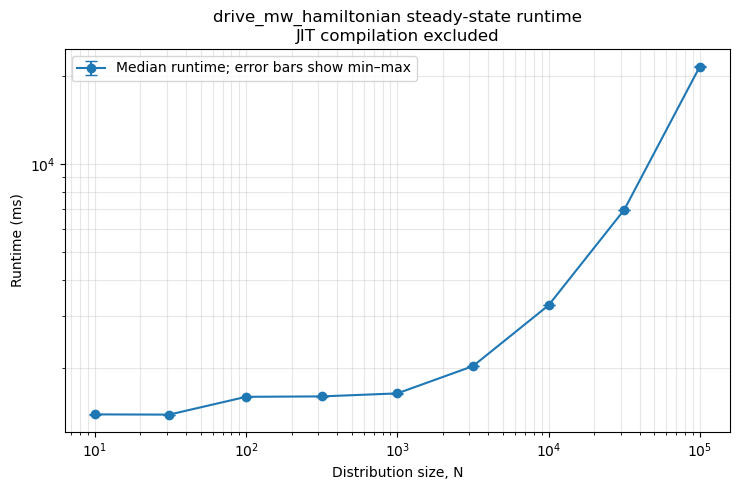

In [ ]:
import gc
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np


def block_until_ready_tree(tree):
    """Block until all JAX array leaves have finished executing.

    Args:
        tree: A JAX pytree containing arrays and/or non-array objects.

    Returns:
        The input pytree after blocking on every compatible array leaf.
    """
    return jax.tree_util.tree_map(
        lambda leaf: (
            leaf.block_until_ready()
            if hasattr(leaf, "block_until_ready")
            else leaf
        ),
        tree,
    )


# -------------------------------------------------------------------------
# Benchmark configuration
# -------------------------------------------------------------------------

# jnp.logspace returns floating-point values, so convert them to Python ints
# before passing them to get_basic_distribution.
N_values = np.asarray(jnp.logspace(1, 5, 9), dtype=np.int64)
N_values = np.unique(N_values)

num_warmup_runs = 1
num_timed_runs = 5

solver_options_args = (
    False,
    "Dopri5",
    int(1e5),
    float(1e-4),
    float(1e-6),
)

included_states = (0, 1, 2, 3)

all_run_times = np.empty(
    (len(N_values), num_timed_runs),
    dtype=float,
)


# -------------------------------------------------------------------------
# Benchmark drive_mw_hamiltonian for each population size
# -------------------------------------------------------------------------

for N_index, N in enumerate(N_values):
    N = int(N)

    print(f"\nBenchmarking N = {N:,}")

    # Distribution creation is intentionally outside the timed region.
    dist = get_basic_distribution(N)

    # Pulse creation and resonant-frequency lookup are also excluded.
    pulse = AnalogPulse(
        length=100e-9,
        apodization=Apodization.COSINE,
        apodization_length=10e-9,
        padding_length=0,
        shift=0,
        amplitude=1,
        frequency=dist.get_emr_freqs(idx=0)[0] * 1e9,
        frequency_chirp=0,
        shape=Shape.TRIANGLE,
        S21_correct=True,
        w_3db=2 * jnp.pi * 2e9,
        phase_offset=np.nan,
        name="",
    )

    # ---------------------------------------------------------------------
    # Warm-up: compile the N-dependent array shapes.
    #
    # This call is not included in all_run_times.
    # ---------------------------------------------------------------------

    for _ in range(num_warmup_runs):
        warmup_result = dist.drive_mw_hamiltonian(
            idx=None,
            pulse=pulse,
            included_states=included_states,
            saveat_final_only=True,
            solver_options_args=solver_options_args,
        )
        block_until_ready_tree(warmup_result)

    # Remove the warm-up output before benchmarking. This is particularly
    # useful for large N when the returned arrays occupy significant memory.
    del warmup_result
    gc.collect()

    # ---------------------------------------------------------------------
    # Timed steady-state executions
    # ---------------------------------------------------------------------

    for run_index in range(num_timed_runs):
        start_time = time.perf_counter()

        benchmark_result = dist.drive_mw_hamiltonian(
            idx=None,
            pulse=pulse,
            included_states=included_states,
            saveat_final_only=True,
            solver_options_args=solver_options_args,
        )

        # JAX dispatch is asynchronous. Blocking here ensures the timer
        # measures execution, not merely operation dispatch.
        block_until_ready_tree(benchmark_result)

        all_run_times[N_index, run_index] = (
            time.perf_counter() - start_time
        )

    run_times_ms = all_run_times[N_index] * 1e3

    print(f"  Mean:   {run_times_ms.mean():.3f} ms")
    print(f"  Median: {np.median(run_times_ms):.3f} ms")
    print(f"  Min:    {run_times_ms.min():.3f} ms")
    print(f"  Max:    {run_times_ms.max():.3f} ms")

    # Release the current distribution and result before constructing the
    # next, potentially much larger, distribution.
    del benchmark_result
    del pulse
    del dist
    gc.collect()


# -------------------------------------------------------------------------
# Calculate summary statistics
# -------------------------------------------------------------------------

run_times_ms = all_run_times * 1e3

mean_times_ms = np.mean(run_times_ms, axis=1)
median_times_ms = np.median(run_times_ms, axis=1)
min_times_ms = np.min(run_times_ms, axis=1)
max_times_ms = np.max(run_times_ms, axis=1)
std_times_ms = np.std(run_times_ms, axis=1, ddof=1)

lower_error_ms = median_times_ms - min_times_ms
upper_error_ms = max_times_ms - median_times_ms


# -------------------------------------------------------------------------
# Print summary table
# -------------------------------------------------------------------------

print("\nSteady-state drive_mw_hamiltonian benchmark")
print("Compilation excluded")
print("-" * 82)
print(
    f"{'N':>10}"
    f"{'Mean (ms)':>15}"
    f"{'Median (ms)':>15}"
    f"{'Min (ms)':>15}"
    f"{'Max (ms)':>15}"
)
print("-" * 82)

for N, mean, median, minimum, maximum in zip(
    N_values,
    mean_times_ms,
    median_times_ms,
    min_times_ms,
    max_times_ms,
):
    print(
        f"{int(N):>10,}"
        f"{mean:>15.3f}"
        f"{median:>15.3f}"
        f"{minimum:>15.3f}"
        f"{maximum:>15.3f}"
    )


# -------------------------------------------------------------------------
# Plot median steady-state runtime
# -------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7.5, 5.0))

ax.errorbar(
    N_values,
    median_times_ms,
    yerr=np.vstack((lower_error_ms, upper_error_ms)),
    marker="o",
    capsize=4,
    linewidth=1.5,
    label="Median runtime; error bars show min–max",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Distribution size, N")
ax.set_ylabel("Runtime (ms)")
ax.set_title(
    "drive_mw_hamiltonian steady-state runtime\n"
    "JIT compilation excluded"
)
ax.grid(True, which="both", alpha=0.3)
ax.legend()
fig.tight_layout()

plt.show()

# Test Excited State Simulation

In [3]:

H0, Hb, Hs_optical, c_ops, optical_transition_offset = dist.get_excitation_hamiltonian(
    idx=0,
    included_states=(0,1,2,3),
    experiment_idx=None,
)
print(H0)
print(H0.data.shape)
print(jnp.mean(H0.data[:8, :8]))
print(jnp.mean(H0.data[8:, 8:]))
print(optical_transition_offset)
print(params.LEVEL_OFFSET - dist.constants.laser_frequency + dist.strain_params[0, 0] + optical_transition_offset)

Quantum array: dims = ((9,), (9,)), bdims = (), shape = (9, 9), type = oper, impl = dense
Qarray data =
[[-0.96194059+0.j  0.        +0.j  0.        +0.j  0.        +0.j
   0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j
   0.        +0.j]
 [ 0.        +0.j -0.96194059+0.j  0.        +0.j  0.        +0.j
   0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j
   0.        +0.j]
 [ 0.        +0.j  0.        +0.j  0.96194059+0.j  0.        +0.j
   0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j
   0.        +0.j]
 [ 0.        +0.j  0.        +0.j  0.        +0.j  0.96194059+0.j
   0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j
   0.        +0.j]
 [ 0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j
  -1.13334724+0.j  0.        +0.j  0.        +0.j  0.        +0.j
   0.        +0.j]
 [ 0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j
   0.        +0.j -1.13334724+0.j  0.        +0.j  0.        +0.j
   0.    

  0% |░░░░░░░░░░| [00:00<?, ?%/s]

100% |██████████| [09:05<00:00,  5.45s/%]


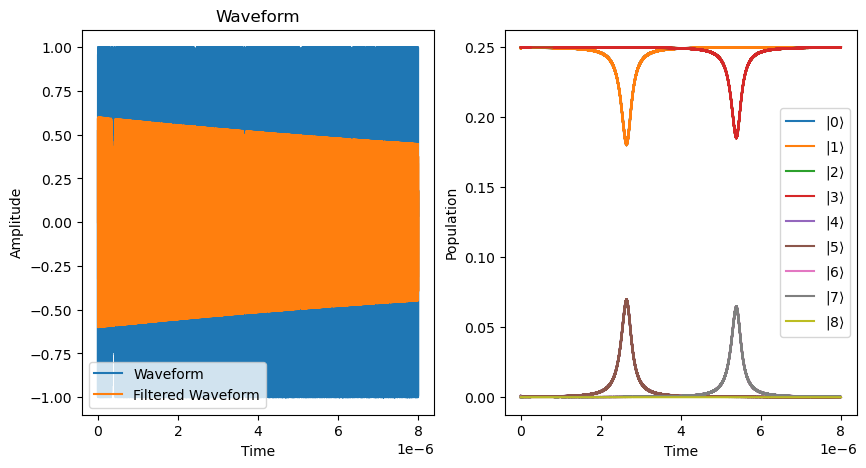

Quantum array: dims = ((9,), (9,)), bdims = (), shape = (9, 9), type = oper, impl = dense
Qarray data =
[[2.49971161e-01-1.77337814e-14j 0.00000000e+00+0.00000000e+00j
  0.00000000e+00+0.00000000e+00j 0.00000000e+00+0.00000000e+00j
  2.46107648e-03-1.01825268e-03j 0.00000000e+00+0.00000000e+00j
  0.00000000e+00+0.00000000e+00j 0.00000000e+00+0.00000000e+00j
  0.00000000e+00+0.00000000e+00j]
 [0.00000000e+00+0.00000000e+00j 2.49971161e-01-1.77337814e-14j
  0.00000000e+00+0.00000000e+00j 0.00000000e+00+0.00000000e+00j
  0.00000000e+00+0.00000000e+00j 2.46107648e-03-1.01825268e-03j
  0.00000000e+00+0.00000000e+00j 0.00000000e+00+0.00000000e+00j
  0.00000000e+00+0.00000000e+00j]
 [0.00000000e+00+0.00000000e+00j 0.00000000e+00+0.00000000e+00j
  2.49860798e-01+0.00000000e+00j 0.00000000e+00+0.00000000e+00j
  0.00000000e+00+0.00000000e+00j 0.00000000e+00+0.00000000e+00j
  5.88291407e-03+1.15908358e-04j 0.00000000e+00+0.00000000e+00j
  0.00000000e+00+0.00000000e+00j]
 [0.00000000e+00+0.0000000

In [11]:
idx = 0
# idx = jnp.arange(0, 100, dtype=jnp.int32)
downsampling = 1
pulse = AnalogPulse(
    length=8e-6,
    apodization=Apodization.COSINE,
    apodization_length=0,
    padding_length=0,
    shift=0,
    amplitude=1,
    frequency=2.5e9,
    frequency_chirp=1e9,
    shape=Shape.SINUSOID,
    S21_correct=False,
    w_3db=2 * jnp.pi * 2e9,
    phase_offset=np.nan,
    name="",
)
rho0 = 0.25 * jqt.ket2dm(jqt.basis(9, 0)) + 0.25 * jqt.ket2dm(jqt.basis(9, 1)) \
     + 0.25 * jqt.ket2dm(jqt.basis(9, 2)) + 0.25 * jqt.ket2dm(jqt.basis(9, 3))
states, filter_states, populations = dist.drive_excitation_hamiltonian(
    idx=idx,
    optical_pulse=pulse,
    included_states=(0, 1, 2, 3),
    saveat_downsampling=downsampling,
    solver_options_args=(True,"Tsit5", int(1e9), 1e-5,1e-7),
    rho0=rho0,
)

tau = make_analog_pulse_time_array(pulse, 1/dist.constants.sampling_rate/1e9, at_time=pulse.length/2)
waveform, envelope, returned_tau = synthesize_analog_pulse(
    pulse=pulse,
    tau=tau,
    at_time=pulse.length / 2,
    all_info=True,
    dphase=0.0,
)
fig, axs = plt.subplots(1,2, figsize=(10, 5))
axs[0].plot(returned_tau, waveform, label="Waveform")
axs[0].plot(returned_tau[::downsampling], filter_states[1], label="Filtered Waveform")
axs[0].set_title("Waveform")
axs[0].set_xlabel("Time")
axs[0].set_ylabel("Amplitude")
axs[0].legend()

for i in range(9):
    axs[1].plot(
        np.asarray(returned_tau[::downsampling]),
        np.asarray(populations[i]),
        label=fr"$|{i}\rangle$",
    )

axs[1].set_xlabel("Time")
axs[1].set_ylabel("Population")
axs[1].legend()
plt.show()
print(states[-1])

RMSE: 1.842651e-03


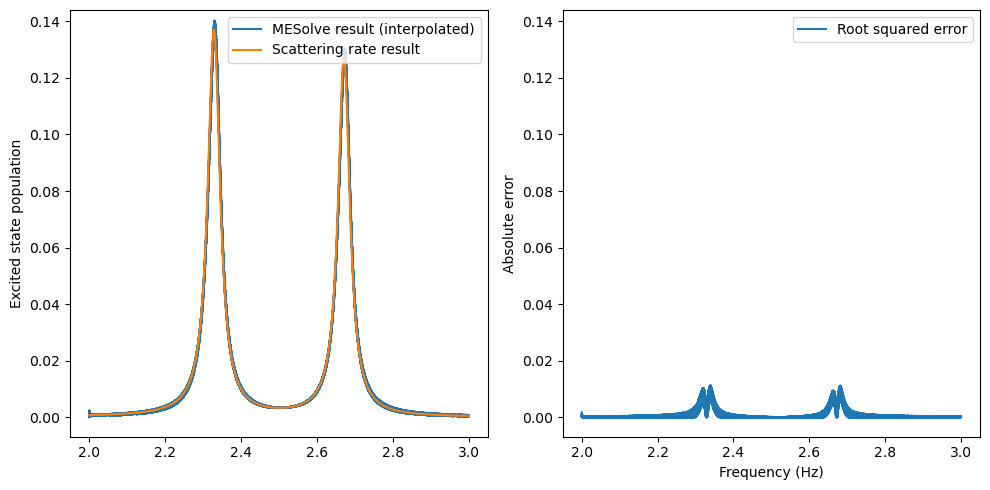

In [ ]:
f, df = 2.5, 1
eom_freqs = jnp.linspace(f-df/2, f+df/2, 100000)
rates, branching_ratios = dist.scattering_rate(idx=idx, eom_frequency=eom_freqs, max_bessel_order=4, sum_counts=True)
scattering_rate_result = np.asarray(rates[:] * dist.excited_state_lifetime[idx])
mesolve_result = np.sum(np.asarray(populations[4:]), axis=0)

factor = df*1e9/8e-6
mesolve_freqs = np.asarray(returned_tau[::downsampling] * factor + (f-df/2)*1e9)
eom_freqs_np = np.asarray(eom_freqs)
mesolve_result_interpolated = np.interp(
    eom_freqs_np,
    mesolve_freqs/1e9,
    mesolve_result,
 )

root_squared_error = np.abs(scattering_rate_result - mesolve_result_interpolated)
rmse = np.sqrt(np.mean(root_squared_error ** 2))
print(f"RMSE: {rmse:.6e}")

fig, axs = plt.subplots(1, 2, figsize=(10, 5), sharex=True)
# axs[0].plot(
#     mesolve_freqs/1e9,
#     mesolve_result,
#     label="MESolve result (original)",
#  )
axs[0].plot(
    eom_freqs_np,
    mesolve_result_interpolated,
    label="MESolve result (interpolated)",
 )
axs[0].plot(eom_freqs_np, scattering_rate_result, label="Scattering rate result")
axs[0].set_ylabel("Excited state population")
axs[0].legend()

axs[1].plot(eom_freqs_np, root_squared_error, label="Root squared error")

pad = (np.max(scattering_rate_result) - np.min(mesolve_result))*0.05
axs[0].set_ylim(np.min(mesolve_result) - pad, np.max(scattering_rate_result) + pad)
axs[1].set_ylim(np.min(mesolve_result) - pad, np.max(scattering_rate_result) + pad)
axs[1].set_xlabel("Frequency (Hz)")
axs[1].set_ylabel("Absolute error")
axs[1].legend()

plt.tight_layout()
plt.show()

# Cyclicity

In [4]:
(dist.get_ple_freqs(idx=idx)[0] - dist.constants.laser_frequency) * 1e9

Array(2.32859335e+09, dtype=float64)

100% |██████████| [1:13:25<00:00, 44.05s/%]
/home/floresh2/.conda/envs/zm/lib/python3.12/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/floresh2/.conda/envs/zm/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


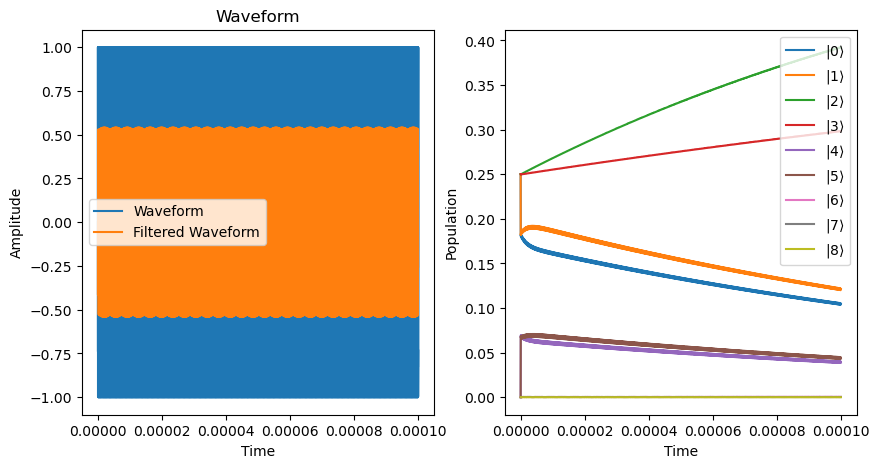

Quantum array: dims = ((9,), (9,)), bdims = (), shape = (9, 9), type = oper, impl = dense
Qarray data =
[[ 1.04784795e-01-6.25958817e-13j -5.18845780e-05+3.35910019e-04j
  -3.66741349e-06-5.54467952e-06j  9.46873280e-07+1.40117622e-06j
  -3.58318277e-02-3.54870746e-02j  7.04251127e-04-1.53057678e-03j
   1.00896733e-05-1.06389123e-05j  1.65354653e-06-2.90971182e-06j
   0.00000000e+00+0.00000000e+00j]
 [-5.18845780e-05-3.35910019e-04j  1.21437669e-01-4.39003660e-13j
  -1.07080554e-06-9.33365677e-07j  2.37775326e-06+1.94292095e-06j
  -1.83440422e-03+2.77189651e-04j  2.44955553e-02+5.24554584e-02j
   1.94132613e-06-2.09119049e-06j  1.75770106e-06-5.68385055e-06j
   0.00000000e+00+0.00000000e+00j]
 [-3.66741349e-06+5.54467952e-06j -1.07080554e-06+9.33365677e-07j
   3.92277592e-01-1.31785495e-11j -2.57508834e-06+2.26284012e-06j
  -4.37080367e-05+1.44066017e-05j  7.05255113e-06+1.38488367e-06j
  -1.17206237e-02+5.77559492e-03j  5.24676681e-04-5.15687321e-04j
   0.00000000e+00+0.00000000e+00j]

In [11]:
idx = 0
# idx = jnp.arange(0, 100, dtype=jnp.int32)
downsampling = 100
pulse = AnalogPulse(
    length=100e-6,
    apodization=Apodization.COSINE,
    apodization_length=0,
    padding_length=0,
    shift=0,
    amplitude=1,
    frequency=(dist.get_ple_freqs(idx=idx)[0] - dist.constants.laser_frequency) * 1e9,
    frequency_chirp=0,
    shape=Shape.SINUSOID,
    S21_correct=False,
    w_3db=2 * jnp.pi * 2e9,
    phase_offset=np.nan,
    name="",
)
rho0 = 0.25 * jqt.ket2dm(jqt.basis(9, 0)) + 0.25 * jqt.ket2dm(jqt.basis(9, 1)) \
     + 0.25 * jqt.ket2dm(jqt.basis(9, 2)) + 0.25 * jqt.ket2dm(jqt.basis(9, 3))
states, filter_states, populations = dist.drive_excitation_hamiltonian(
    idx=idx,
    optical_pulse=pulse,
    included_states=(0, 1, 2, 3),
    saveat_downsampling=downsampling,
    solver_options_args=(True,"Tsit5", int(1e9), 1e-4,1e-6),
    rho0=rho0,
    experiment_idx=0
)

tau = make_analog_pulse_time_array(pulse, 1/dist.constants.sampling_rate/1e9, at_time=pulse.length/2)
waveform, envelope, returned_tau = synthesize_analog_pulse(
    pulse=pulse,
    tau=tau,
    at_time=pulse.length / 2,
    all_info=True,
    dphase=0.0,
)
fig, axs = plt.subplots(1,2, figsize=(10, 5))
axs[0].plot(returned_tau, waveform, label="Waveform")
axs[0].plot(returned_tau[::downsampling], filter_states[1], label="Filtered Waveform")
axs[0].set_title("Waveform")
axs[0].set_xlabel("Time")
axs[0].set_ylabel("Amplitude")
axs[0].legend()

for i in range(9):
    axs[1].plot(
        np.asarray(returned_tau[::downsampling]),
        np.asarray(populations[i]),
        label=fr"$|{i}\rangle$",
    )

axs[1].set_xlabel("Time")
axs[1].set_ylabel("Population")
axs[1].legend()
plt.show()
print(states[-1])

In [10]:
idx=0
scattering_rates, branching_ratios = dist.scattering_rate(idx=idx, eom_frequency=0, experiment_idx=None)
print(branching_ratios)

[[9.97074905e-01 2.75256657e-03 1.42949496e-04 2.95788099e-05
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [2.75422568e-03 9.97195541e-01 2.77030221e-05 2.25305559e-05
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.43207014e-04 2.92172349e-05 9.96393891e-01 3.43368453e-03
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [2.76621852e-05 2.26754515e-05 3.43545625e-03 9.96514206e-01
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [9.96916635e-01 2.82634014e-03 2.13150791e-04 4.38737577e-05
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [2.82776174e-03 9.97106250e-01 4.20531498e-05 2.39353334e-05
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [2.13093703e-04 4.34664806e-05 9.96402211e-01 3.34122930e-03
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [4.25092451e-05 2.39436049e-05 3.34258554e-03 9.96590962e-01
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]]

# PLE Qutip Raw Model

/home/floresh2/.conda/envs/zm/lib/python3.12/site-packages/qutip/solver/options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


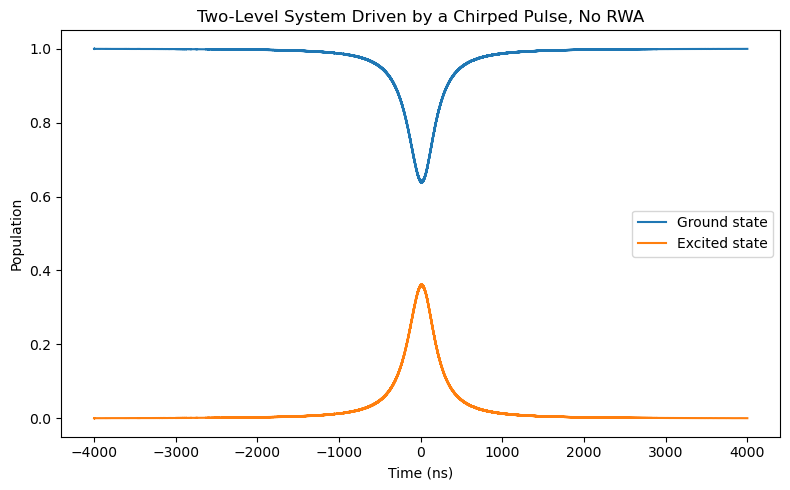

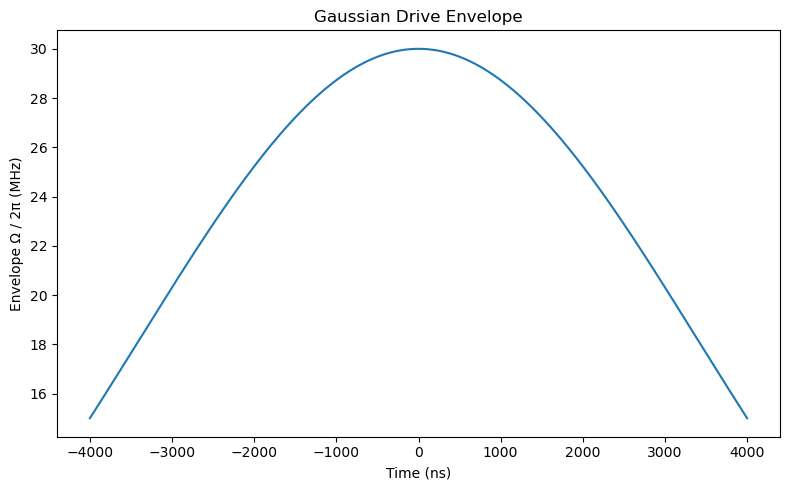

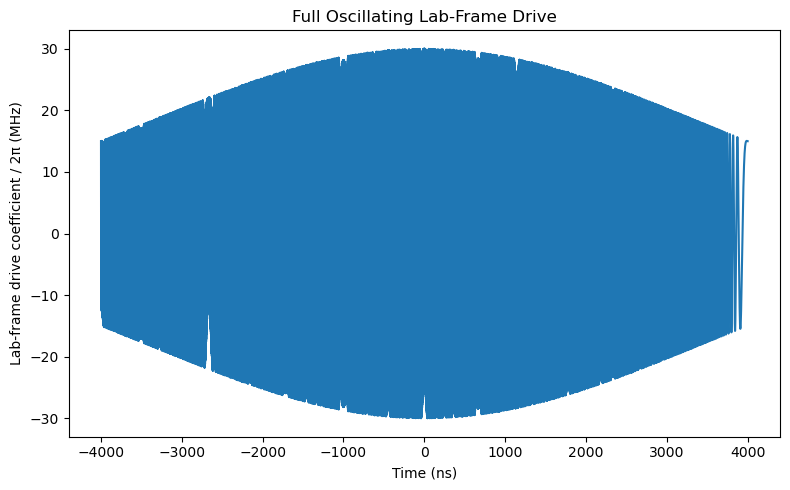

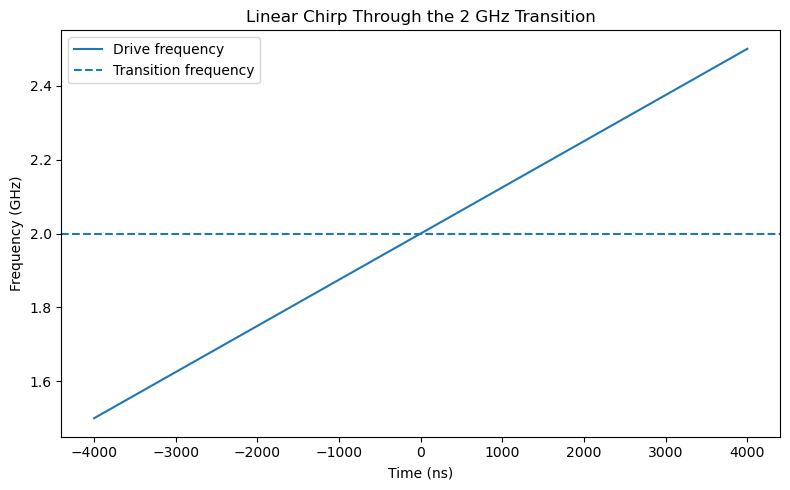

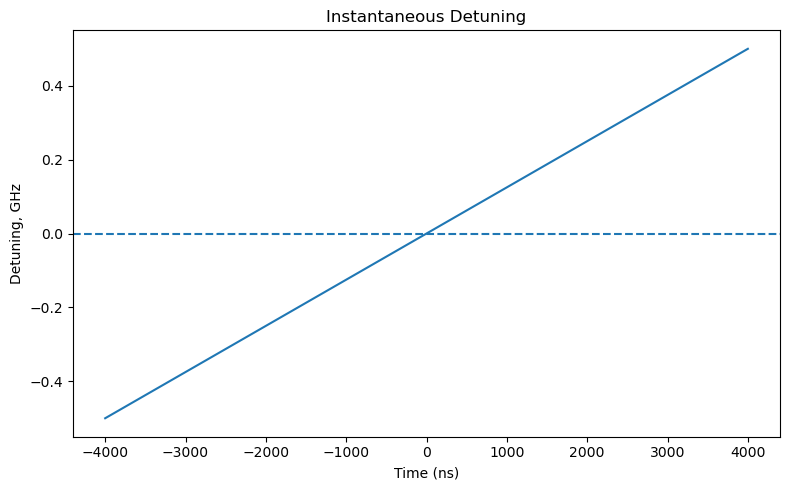

Final ground-state population:  0.999822
Final excited-state population: 0.000178
Peak Rabi amplitude:            30.000 MHz
Excited-state lifetime:         6.000 ns
Decay rate gamma:               0.166667 1/ns


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import basis, mesolve, Options

# ============================================================
# Parameters
# ============================================================

# Two-level system
transition_freq_GHz = 2.0      # |g> -> |e> transition frequency, cycles/ns
decay_time_ns = 6.0            # excited-state lifetime
gamma = 1.0 / decay_time_ns    # decay rate, 1/ns

# Chirped pulse
center_freq_GHz = 2.0          # chirp center frequency, cycles/ns
chirp_width_GHz = 1.0          # total chirp width, cycles/ns
rabi_amp_MHz = 30.0            # peak Rabi amplitude, MHz

# Pulse timing
pulse_duration_ns = 8000.0       # total simulated pulse duration
pulse_fwhm_ns = 8000.0           # Gaussian amplitude FWHM

# Numerical resolution
num_time_points = 20000        # need many points because this is lab-frame, non-RWA

# ============================================================
# Unit conversions
# ============================================================
# Time is in ns.
# 1 GHz = 1 cycle/ns.
# Angular frequencies are in rad/ns.

omega0 = 2 * np.pi * transition_freq_GHz
Omega0 = 2 * np.pi * rabi_amp_MHz * 1e-3  # MHz -> GHz -> rad/ns

sigma_t = pulse_fwhm_ns / (2 * np.sqrt(2 * np.log(2)))

# ============================================================
# Time axis
# ============================================================

tlist = np.linspace(
    -pulse_duration_ns / 2,
    pulse_duration_ns / 2,
    num_time_points,
)

# ============================================================
# Operators
# ============================================================

g = basis(2, 0)
e = basis(2, 1)

proj_g = g * g.dag()
proj_e = e * e.dag()

sigma_plus = e * g.dag()
sigma_minus = g * e.dag()
sigma_x = sigma_plus + sigma_minus

# ============================================================
# Chirped pulse definitions
# ============================================================

def gaussian_envelope(t):
    """
    Gaussian Rabi envelope.
    Returns angular frequency in rad/ns.
    """
    return Omega0 * np.exp(-0.5 * (t / sigma_t) ** 2)


def instantaneous_drive_freq_GHz(t):
    """
    Linear chirp centered at center_freq_GHz.

    With default values:
        t = -20 ns -> 1.5 GHz
        t =   0 ns -> 2.0 GHz
        t = +20 ns -> 2.5 GHz
    """
    return center_freq_GHz + chirp_width_GHz * t / pulse_duration_ns


def drive_phase(t):
    """
    Phase of the chirped drive.

    phi(t) = 2pi * integral f(t) dt

    where f(t) = center_freq_GHz + chirp_width_GHz * t / pulse_duration_ns.
    """
    return 2 * np.pi * (
        center_freq_GHz * t
        + 0.5 * chirp_width_GHz * t**2 / pulse_duration_ns
    )


def lab_frame_drive_coeff(t, args=None):
    """
    Full non-RWA lab-frame drive coefficient:
        Omega(t) cos(phi(t))
    """
    return gaussian_envelope(t) * np.cos(drive_phase(t))


# ============================================================
# Full lab-frame Hamiltonian, no RWA
# ============================================================
# Ground-state energy is set to 0.
# Excited-state energy is omega0.
#
# H(t) = omega0 |e><e| + Omega(t) cos(phi(t)) sigma_x

H0 = omega0 * proj_e

H = [
    H0,
    [sigma_x, lab_frame_drive_coeff],
]

# ============================================================
# Dissipation: excited-state decay |e> -> |g>
# ============================================================

c_ops = [
    np.sqrt(gamma) * sigma_minus
]

# ============================================================
# Solve
# ============================================================

psi0 = g

result = mesolve(
    H,
    psi0,
    tlist,
    c_ops=c_ops,
    e_ops=[proj_g, proj_e],
    options=Options(
        nsteps=100000,
        atol=1e-9,
        rtol=1e-7,
    ),
)

Pg = np.real(result.expect[0])
Pe = np.real(result.expect[1])

# ============================================================
# Plot pulse and dynamics
# ============================================================

Omega_t_MHz = np.array([gaussian_envelope(t) for t in tlist]) / (2 * np.pi) * 1e3
drive_t_MHz = np.array([lab_frame_drive_coeff(t) for t in tlist]) / (2 * np.pi) * 1e3
drive_freq_t_GHz = np.array([instantaneous_drive_freq_GHz(t) for t in tlist])
detuning_t_GHz = drive_freq_t_GHz - transition_freq_GHz

plt.figure(figsize=(8, 5))
plt.plot(tlist, Pg, label="Ground state")
plt.plot(tlist, Pe, label="Excited state")
plt.xlabel("Time (ns)")
plt.ylabel("Population")
plt.title("Two-Level System Driven by a Chirped Pulse, No RWA")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(tlist, Omega_t_MHz)
plt.xlabel("Time (ns)")
plt.ylabel("Envelope Ω / 2π (MHz)")
plt.title("Gaussian Drive Envelope")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(tlist, drive_t_MHz)
plt.xlabel("Time (ns)")
plt.ylabel("Lab-frame drive coefficient / 2π (MHz)")
plt.title("Full Oscillating Lab-Frame Drive")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(tlist, drive_freq_t_GHz, label="Drive frequency")
plt.axhline(transition_freq_GHz, linestyle="--", label="Transition frequency")
plt.xlabel("Time (ns)")
plt.ylabel("Frequency (GHz)")
plt.title("Linear Chirp Through the 2 GHz Transition")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(tlist, detuning_t_GHz)
plt.axhline(0.0, linestyle="--")
plt.xlabel("Time (ns)")
plt.ylabel("Detuning, GHz")
plt.title("Instantaneous Detuning")
plt.tight_layout()
plt.show()

print(f"Final ground-state population:  {Pg[-1]:.6f}")
print(f"Final excited-state population: {Pe[-1]:.6f}")
print(f"Peak Rabi amplitude:            {rabi_amp_MHz:.3f} MHz")
print(f"Excited-state lifetime:         {decay_time_ns:.3f} ns")
print(f"Decay rate gamma:               {gamma:.6f} 1/ns")

In [ ]:
import os

# ============================================================
# JAX configuration
# ============================================================
# These environment variables must be set before importing JAX,
# jax.numpy, jaxquantum, diffrax, or anything that imports them.

os.environ["JAX_PLATFORMS"] = "gpu"
os.environ["JAX_ENABLE_X64"] = "True"

from jax import config

config.update("jax_enable_x64", True)

# These can be temporarily enabled while diagnosing NaN/Inf failures.
# They may substantially slow down execution.
config.update("jax_debug_nans", False)
config.update("jax_debug_infs", False)

import time

import jax
import jax.numpy as jnp
import jaxquantum as jqt
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Confirm GPU and precision
# ============================================================

print("JAX version:", jax.__version__)
print("JAXQuantum version:", jqt.__version__)
# print("Default backend:", jax.default_backend())
print("Devices:", jax.devices())
print("x64 enabled:", jax.config.read("jax_enable_x64"))

if jax.default_backend() != "gpu":
    raise RuntimeError(
        "JAX did not initialize a GPU backend. Restart the kernel and "
        "verify that the GPU-enabled JAX installation is available."
    )

if not jax.config.read("jax_enable_x64"):
    raise RuntimeError(
        "JAX x64 mode is disabled. Restart the kernel and run this cell "
        "before importing any JAX-dependent package."
    )

# ============================================================
# Parameters
# ============================================================

real_dtype = jnp.float64
complex_dtype = jnp.complex128

transition_freq_GHz = jnp.asarray(2.0, dtype=real_dtype)
decay_time_ns = jnp.asarray(6.0, dtype=real_dtype)
gamma = 1.0 / decay_time_ns

center_freq_GHz = jnp.asarray(2.0, dtype=real_dtype)
chirp_width_GHz = jnp.asarray(1.0, dtype=real_dtype)
rabi_amp_MHz = jnp.asarray(30.0, dtype=real_dtype)

pulse_duration_ns = jnp.asarray(8000.0, dtype=real_dtype)
pulse_fwhm_ns = jnp.asarray(8000.0, dtype=real_dtype)

num_time_points = 20_000

omega0 = (
    jnp.asarray(2.0, dtype=real_dtype)
    * jnp.pi
    * transition_freq_GHz
)

Omega0 = (
    jnp.asarray(2.0, dtype=real_dtype)
    * jnp.pi
    * rabi_amp_MHz
    * jnp.asarray(1e-3, dtype=real_dtype)
)

sigma_t = pulse_fwhm_ns / (
    jnp.asarray(2.0, dtype=real_dtype)
    * jnp.sqrt(
        jnp.asarray(2.0, dtype=real_dtype)
        * jnp.log(jnp.asarray(2.0, dtype=real_dtype))
    )
)

t_start = -pulse_duration_ns / 2.0
t_stop = pulse_duration_ns / 2.0

# Times at which density matrices will be returned.
save_tlist = jnp.linspace(
    t_start,
    t_stop,
    num_time_points,
    dtype=real_dtype,
)

# ------------------------------------------------------------
# Important:
# JAXQuantum uses
#
#     dt0 = integration_tlist[1] - integration_tlist[0]
#
# as Diffrax's initial adaptive step.
#
# Do not let the 20,000-point output grid determine dt0.
# A 0.01 ns initial step resolves the fastest 2.5 GHz carrier
# period with 40 initial points per cycle.
# ------------------------------------------------------------

initial_step_ns = jnp.asarray(0.01, dtype=real_dtype)

integration_tlist = jnp.asarray(
    [
        t_start,
        t_start + initial_step_ns,
        t_stop,
    ],
    dtype=real_dtype,
)

# ============================================================
# States and operators
# ============================================================

# Multiplying by an explicitly complex128 scalar ensures that
# basis states and all derived objects are complex128.
complex_one = jnp.asarray(1.0 + 0.0j, dtype=complex_dtype)

g = complex_one * jqt.basis(2, 0)
e = complex_one * jqt.basis(2, 1)

proj_g = g @ g.dag()
proj_e = e @ e.dag()

sigma_plus = e @ g.dag()
sigma_minus = g @ e.dag()
sigma_x = sigma_plus + sigma_minus

rho0 = g.to_dm()

H0 = omega0 * proj_e

c_ops = jqt.Qarray.from_list(
    [
        jnp.sqrt(gamma) * sigma_minus,
    ]
)

# ============================================================
# Verify every important dtype before compiling
# ============================================================

print("\nDtype audit")
print("save_tlist dtype:       ", save_tlist.dtype)
print("integration_tlist dtype:", integration_tlist.dtype)
print("g dtype:                ", g.data.dtype)
print("rho0 dtype:             ", rho0.data.dtype)
print("H0 dtype:               ", H0.data.dtype)
print("sigma_x dtype:          ", sigma_x.data.dtype)
print("c_ops dtype:            ", c_ops.data.dtype)

expected_real = jnp.dtype(jnp.float64)
expected_complex = jnp.dtype(jnp.complex128)

if save_tlist.dtype != expected_real:
    raise TypeError(f"save_tlist has unexpected dtype {save_tlist.dtype}")

if integration_tlist.dtype != expected_real:
    raise TypeError(
        f"integration_tlist has unexpected dtype "
        f"{integration_tlist.dtype}"
    )

for name, array in {
    "rho0": rho0.data,
    "H0": H0.data,
    "sigma_x": sigma_x.data,
    "c_ops": c_ops.data,
}.items():
    if array.dtype != expected_complex:
        raise TypeError(
            f"{name} is {array.dtype}, but complex128 is required."
        )

# ============================================================
# Chirped pulse
# ============================================================

def gaussian_envelope(t):
    """Gaussian Rabi-frequency envelope in rad/ns."""
    t = jnp.asarray(t, dtype=real_dtype)

    return Omega0 * jnp.exp(
        -0.5 * jnp.square(t / sigma_t)
    )


def instantaneous_drive_freq_GHz(t):
    """Instantaneous drive frequency in GHz."""
    t = jnp.asarray(t, dtype=real_dtype)

    return (
        center_freq_GHz
        + chirp_width_GHz * t / pulse_duration_ns
    )


def drive_cycles(t):
    """
    Integrated drive phase expressed in cycles rather than radians.

    The physical phase is 2*pi*drive_cycles(t).
    """
    t = jnp.asarray(t, dtype=real_dtype)

    return (
        center_freq_GHz * t
        + 0.5
        * chirp_width_GHz
        * jnp.square(t)
        / pulse_duration_ns
    )


def wrapped_drive_phase(t):
    """
    Equivalent phase reduced to [-pi, pi).

    Reducing the argument before cos() improves CPU/GPU agreement for
    this very long pulse. Mathematically, this is exactly equivalent
    because cosine is periodic.
    """
    cycles = drive_cycles(t)

    wrapped_cycles = (
        jnp.remainder(cycles + 0.5, 1.0) - 0.5
    )

    return 2.0 * jnp.pi * wrapped_cycles


def lab_frame_drive_coeff(t):
    """
    Full non-RWA drive coefficient:

        Omega(t) cos(phi(t)).
    """
    return (
        gaussian_envelope(t)
        * jnp.cos(wrapped_drive_phase(t))
    )


def hamiltonian(t):
    """
    Full lab-frame Hamiltonian without the rotating-wave approximation.
    """
    return H0 + lab_frame_drive_coeff(t) * sigma_x


# ============================================================
# Solver
# ============================================================

solver_options = jqt.SolverOptions.create(
    progress_meter=False,
    solver="Dopri8",
    max_steps=2_000_000,
    rtol=1e-8,
    atol=1e-10,
)


@jax.jit
def mesolve_jit():
    states = jqt.mesolve(
        hamiltonian,
        rho0,
        integration_tlist,
        saveat_tlist=save_tlist,
        c_ops=c_ops,
        solver_options=solver_options,
    )

    return states.data


# ============================================================
# Compile and run
# ============================================================

compile_start = time.perf_counter()

compiled_mesolve = mesolve_jit.lower().compile()

compile_time_s = time.perf_counter() - compile_start

run_start = time.perf_counter()

rho_t = compiled_mesolve()
rho_t.block_until_ready()

run_time_s = time.perf_counter() - run_start

cached_start = time.perf_counter()

rho_t_cached = compiled_mesolve()
rho_t_cached.block_until_ready()

cached_run_time_s = time.perf_counter() - cached_start

# ============================================================
# Diagnostics
# ============================================================

rho_t_np = np.asarray(rho_t)
tlist_np = np.asarray(save_tlist)

if not np.all(np.isfinite(rho_t_np)):
    bad_indices = np.argwhere(~np.isfinite(rho_t_np))

    raise FloatingPointError(
        "The GPU result contains NaN or Inf values. "
        f"First bad array index: {bad_indices[0].tolist()}"
    )

Pg = np.real(rho_t_np[:, 0, 0])
Pe = np.real(rho_t_np[:, 1, 1])

traces = np.trace(
    rho_t_np,
    axis1=-2,
    axis2=-1,
)

trace_error = np.max(np.abs(traces - 1.0))

hermiticity_error = np.max(
    np.abs(
        rho_t_np
        - np.swapaxes(rho_t_np.conj(), -1, -2)
    )
)

eigenvalues = np.linalg.eigvalsh(rho_t_np)
minimum_density_eigenvalue = np.min(eigenvalues)

population_minimum = min(np.min(Pg), np.min(Pe))
population_maximum = max(np.max(Pg), np.max(Pe))

print("\nNumerical diagnostics")
print(f"Compile time:                    {compile_time_s:.6f} s")
print(f"First run time:                  {run_time_s:.6f} s")
print(f"Cached run time:                 {cached_run_time_s:.6f} s")
print(f"Maximum trace error:             {trace_error:.3e}")
print(f"Maximum Hermiticity error:       {hermiticity_error:.3e}")
print(
    f"Minimum density eigenvalue:      "
    f"{minimum_density_eigenvalue:.3e}"
)
print(f"Minimum population:              {population_minimum:.9f}")
print(f"Maximum population:              {population_maximum:.9f}")
print(f"Final ground population:         {Pg[-1]:.9f}")
print(f"Final excited population:        {Pe[-1]:.9f}")
print(f"Peak excited population:         {np.max(Pe):.9f}")

if trace_error > 1e-6:
    raise RuntimeError(
        f"Trace conservation failed: maximum error = {trace_error:.3e}"
    )

if hermiticity_error > 1e-6:
    raise RuntimeError(
        "Hermiticity failed: maximum error = "
        f"{hermiticity_error:.3e}"
    )

if minimum_density_eigenvalue < -1e-5:
    raise RuntimeError(
        "The density matrix lost positivity: minimum eigenvalue = "
        f"{minimum_density_eigenvalue:.3e}"
    )

if population_minimum < -1e-5 or population_maximum > 1.0 + 1e-5:
    raise RuntimeError(
        "A population left the physical range: "
        f"[{population_minimum:.9f}, {population_maximum:.9f}]"
    )

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    tlist_np,
    Pg,
    label="Ground state",
)

plt.plot(
    tlist_np,
    Pe,
    label="Excited state",
)

plt.xlabel("Time (ns)")
plt.ylabel("Population")
plt.title("GPU JAXQuantum Chirped-Pulse Dynamics, No RWA")
plt.legend()
plt.tight_layout()
plt.show()

JAX version: 0.10.1
JAXQuantum version: 0.3.0
Devices: [CudaDevice(id=0)]
x64 enabled: True

Dtype audit
save_tlist dtype:        float64
integration_tlist dtype: float64
g dtype:                 complex128
rho0 dtype:              complex128
H0 dtype:                complex128
sigma_x dtype:           complex128
c_ops dtype:             complex128


JAX version: 0.10.1
JAXQuantum version: 0.3.0
Diffrax version: 0.7.2
Devices: [CudaDevice(id=0)]
x64 enabled: True

Timing
Compile time:                  0.787034 s
First run time:                350.532777 s
Cached run time:               350.519076 s

Physical results
Final ground population:       0.999822396
Final excited population:      0.000177604
Peak excited population:       0.362271795
Peak excited time:             11.800590030 ns

Numerical diagnostics
Maximum trace error:           3.027e-14
Maximum Hermiticity error:     4.566e-15
Minimum density eigenvalue:    0.000e+00
Minimum population:            0.000000000
Maximum population:            1.000000000


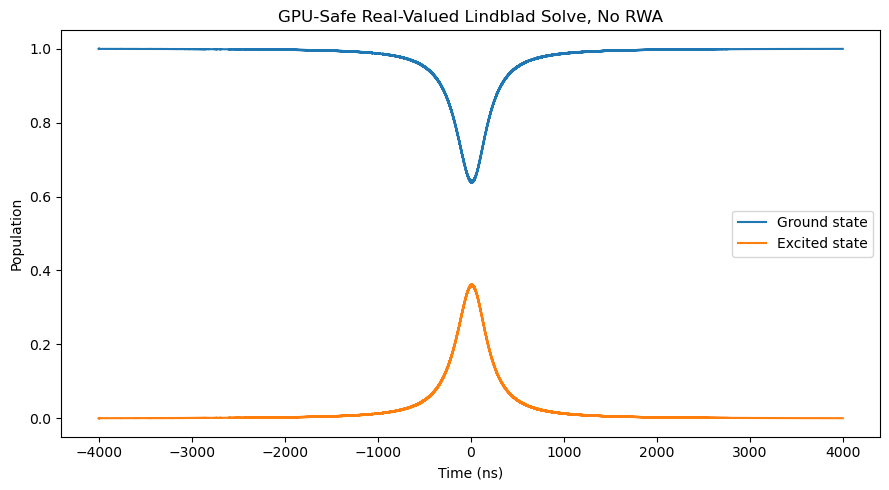

In [ ]:
import os

# ============================================================
# JAX configuration
# ============================================================
# Run this in a fresh kernel before importing JAX.

os.environ["JAX_PLATFORMS"] = "gpu"
os.environ["JAX_ENABLE_X64"] = "True"

from jax import config

config.update("jax_enable_x64", True)
config.update("jax_default_matmul_precision", "highest")

import time

import diffrax
import jax
import jax.numpy as jnp
import jaxquantum as jqt
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Confirm backend and versions
# ============================================================

print("JAX version:", jax.__version__)
print("JAXQuantum version:", jqt.__version__)
print("Diffrax version:", diffrax.__version__)
# print("Default backend:", jax.default_backend())
print("Devices:", jax.devices())
print("x64 enabled:", jax.config.read("jax_enable_x64"))

if jax.default_backend() != "gpu":
    raise RuntimeError(
        "JAX did not initialize the GPU backend. Restart the kernel "
        "and run the configuration lines before importing JAX."
    )

if not jax.config.read("jax_enable_x64"):
    raise RuntimeError("JAX x64 mode is disabled.")

# ============================================================
# Parameters
# ============================================================

real_dtype = jnp.float64
complex_dtype = jnp.complex128

# Two-level system
transition_freq_GHz = jnp.asarray(2.0, dtype=real_dtype)
decay_time_ns = jnp.asarray(6.0, dtype=real_dtype)
gamma = 1.0 / decay_time_ns

# Chirped pulse
center_freq_GHz = jnp.asarray(2.0, dtype=real_dtype)
chirp_width_GHz = jnp.asarray(1.0, dtype=real_dtype)
rabi_amp_MHz = jnp.asarray(30.0, dtype=real_dtype)

# Pulse timing
pulse_duration_ns = jnp.asarray(8000.0, dtype=real_dtype)
pulse_fwhm_ns = jnp.asarray(8000.0, dtype=real_dtype)

# Saved output points
num_time_points = 20_000

# Angular frequencies in rad/ns
omega0 = 2.0 * jnp.pi * transition_freq_GHz
Omega0 = 2.0 * jnp.pi * rabi_amp_MHz * 1e-3

sigma_t = pulse_fwhm_ns / (
    2.0 * jnp.sqrt(2.0 * jnp.log(2.0))
)

t_start = -pulse_duration_ns / 2.0
t_stop = pulse_duration_ns / 2.0

save_tlist = jnp.linspace(
    t_start,
    t_stop,
    num_time_points,
    dtype=real_dtype,
)

# ============================================================
# JAXQuantum states and operators
# ============================================================

complex_one = jnp.asarray(1.0 + 0.0j, dtype=complex_dtype)

g = complex_one * jqt.basis(2, 0)
e = complex_one * jqt.basis(2, 1)

proj_g = (g @ g.dag()).data.astype(complex_dtype)
proj_e = (e @ e.dag()).data.astype(complex_dtype)

sigma_plus = (e @ g.dag()).data.astype(complex_dtype)
sigma_minus = (g @ e.dag()).data.astype(complex_dtype)
sigma_x = sigma_plus + sigma_minus

rho0_complex = g.to_dm().data.astype(complex_dtype)

H0 = omega0 * proj_e

# Collapse operator L = sqrt(gamma) |g><e|
L = jnp.sqrt(gamma) * sigma_minus
L_dag = jnp.conj(jnp.swapaxes(L, -1, -2))
L_dag_L = L_dag @ L

# ============================================================
# Chirped pulse
# ============================================================

def gaussian_envelope(t):
    """
    Gaussian Rabi envelope in rad/ns.
    """
    return Omega0 * jnp.exp(
        -0.5 * jnp.square(t / sigma_t)
    )


def instantaneous_drive_freq_GHz(t):
    """
    Instantaneous drive frequency in GHz.
    """
    return (
        center_freq_GHz
        + chirp_width_GHz * t / pulse_duration_ns
    )


def drive_cycles(t):
    """
    Integrated phase expressed in cycles.
    """
    return (
        center_freq_GHz * t
        + 0.5
        * chirp_width_GHz
        * jnp.square(t)
        / pulse_duration_ns
    )


def wrapped_drive_phase(t):
    """
    Drive phase reduced to [-pi, pi).

    This avoids evaluating cosine on unnecessarily large arguments.
    """
    cycles = drive_cycles(t)

    wrapped_cycles = (
        jnp.remainder(cycles + 0.5, 1.0) - 0.5
    )

    return 2.0 * jnp.pi * wrapped_cycles


def lab_frame_drive_coeff(t):
    """
    Full non-RWA lab-frame coefficient:

        Omega(t) cos(phi(t)).
    """
    return (
        gaussian_envelope(t)
        * jnp.cos(wrapped_drive_phase(t))
    )


def hamiltonian_data(t):
    """
    Full lab-frame Hamiltonian as a complex128 JAX array.
    """
    return H0 + lab_frame_drive_coeff(t) * sigma_x


# ============================================================
# Real-valued density-matrix representation
# ============================================================
# Diffrax warns that directly integrating a complex-valued state
# may not produce correct results. We therefore store
#
#     y[0] = Re(rho)
#     y[1] = Im(rho)
#
# so the ODE state itself is entirely float64.

def complex_to_real_state(rho):
    """
    Convert a complex density matrix to a real-valued ODE state.
    """
    return jnp.stack(
        (
            jnp.real(rho),
            jnp.imag(rho),
        ),
        axis=0,
    )


def real_state_to_complex(y):
    """
    Reconstruct the complex density matrix.
    """
    return y[0] + 1j * y[1]


rho0_real = complex_to_real_state(rho0_complex)

# ============================================================
# Exact Lindblad master-equation RHS
# ============================================================

def master_equation_rhs(t, y, args):
    """
    Full Lindblad master equation.

    No Hermiticity shortcut is used. In particular, the right
    anticommutator term is computed as

        rho @ (L_dag @ L)

    rather than reconstructing it from a conjugate transpose.
    """
    del args

    rho = real_state_to_complex(y)
    H = hamiltonian_data(t)

    # Hamiltonian contribution
    drho = -1j * (H @ rho - rho @ H)

    # Exact dissipator:
    #
    # D[L](rho)
    #   = L rho L†
    #     - 1/2 (L†L rho + rho L†L)
    drho = drho + (
        L @ rho @ L_dag
        - 0.5 * (
            L_dag_L @ rho
            + rho @ L_dag_L
        )
    )

    # Return a real-valued derivative.
    return jnp.stack(
        (
            jnp.real(drho),
            jnp.imag(drho),
        ),
        axis=0,
    )


# ============================================================
# Diffrax solver
# ============================================================

term = diffrax.ODETerm(master_equation_rhs)
solver = diffrax.Tsit5()

stepsize_controller = diffrax.PIDController(
    rtol=1e-8,
    atol=1e-10,
)


@jax.jit
def mesolve_gpu_safe():
    """
    GPU-safe, real-valued Lindblad solve.
    """
    solution = diffrax.diffeqsolve(
        terms=term,
        solver=solver,
        t0=t_start,
        t1=t_stop,
        dt0=jnp.asarray(0.01, dtype=real_dtype),
        y0=rho0_real,
        args=None,
        saveat=diffrax.SaveAt(ts=save_tlist),
        stepsize_controller=stepsize_controller,
        max_steps=2_000_000,
        throw=True,
    )

    return solution.ys


# ============================================================
# Compile
# ============================================================

compile_start = time.perf_counter()

compiled_mesolve = mesolve_gpu_safe.lower().compile()

compile_time_s = time.perf_counter() - compile_start

# ============================================================
# First execution
# ============================================================

run_start = time.perf_counter()

rho_real_t = compiled_mesolve()
rho_real_t.block_until_ready()

first_run_time_s = time.perf_counter() - run_start

# ============================================================
# Cached execution
# ============================================================

cached_start = time.perf_counter()

rho_real_t_cached = compiled_mesolve()
rho_real_t_cached.block_until_ready()

cached_run_time_s = time.perf_counter() - cached_start

# ============================================================
# Reconstruct density matrices
# ============================================================
# Output shape:
#
#     (num_time_points, 2, 2, 2)
#
# where axis 1 contains real and imaginary components.

rho_t = (
    rho_real_t[:, 0, :, :]
    + 1j * rho_real_t[:, 1, :, :]
)

rho_t_np = np.asarray(rho_t)
tlist_np = np.asarray(save_tlist)

# ============================================================
# Populations and diagnostics
# ============================================================

Pg = np.real(rho_t_np[:, 0, 0])
Pe = np.real(rho_t_np[:, 1, 1])

traces = np.trace(
    rho_t_np,
    axis1=-2,
    axis2=-1,
)

trace_error = np.max(
    np.abs(traces - 1.0)
)

hermiticity_error = np.max(
    np.abs(
        rho_t_np
        - np.swapaxes(
            rho_t_np.conj(),
            -1,
            -2,
        )
    )
)

density_eigenvalues = np.linalg.eigvalsh(rho_t_np)

minimum_density_eigenvalue = np.min(
    density_eigenvalues
)

population_minimum = min(
    np.min(Pg),
    np.min(Pe),
)

population_maximum = max(
    np.max(Pg),
    np.max(Pe),
)

peak_index = int(np.argmax(Pe))
peak_time_ns = tlist_np[peak_index]
peak_excited_population = Pe[peak_index]

# ============================================================
# Print diagnostics
# ============================================================

print("\nTiming")
print(f"Compile time:                  {compile_time_s:.6f} s")
print(f"First run time:                {first_run_time_s:.6f} s")
print(f"Cached run time:               {cached_run_time_s:.6f} s")

print("\nPhysical results")
print(f"Final ground population:       {Pg[-1]:.9f}")
print(f"Final excited population:      {Pe[-1]:.9f}")
print(f"Peak excited population:       {peak_excited_population:.9f}")
print(f"Peak excited time:             {peak_time_ns:.9f} ns")

print("\nNumerical diagnostics")
print(f"Maximum trace error:           {trace_error:.3e}")
print(f"Maximum Hermiticity error:     {hermiticity_error:.3e}")
print(
    f"Minimum density eigenvalue:    "
    f"{minimum_density_eigenvalue:.3e}"
)
print(f"Minimum population:            {population_minimum:.9f}")
print(f"Maximum population:            {population_maximum:.9f}")

# ============================================================
# Fail loudly if the result is unphysical
# ============================================================

if not np.all(np.isfinite(rho_t_np)):
    raise FloatingPointError(
        "The solution contains NaN or Inf values."
    )

if trace_error > 1e-6:
    raise RuntimeError(
        "Trace conservation failed: "
        f"maximum error = {trace_error:.3e}"
    )

if hermiticity_error > 1e-6:
    raise RuntimeError(
        "Hermiticity failed: "
        f"maximum error = {hermiticity_error:.3e}"
    )

if minimum_density_eigenvalue < -1e-5:
    raise RuntimeError(
        "The density matrix lost positivity: "
        f"minimum eigenvalue = "
        f"{minimum_density_eigenvalue:.3e}"
    )

if (
    population_minimum < -1e-5
    or population_maximum > 1.0 + 1e-5
):
    raise RuntimeError(
        "A population left the physical range: "
        f"[{population_minimum:.9f}, "
        f"{population_maximum:.9f}]"
    )

# ============================================================
# Plot populations
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    tlist_np,
    Pg,
    label="Ground state",
)

plt.plot(
    tlist_np,
    Pe,
    label="Excited state",
)

plt.xlabel("Time (ns)")
plt.ylabel("Population")
plt.title(
    "GPU-Safe Real-Valued Lindblad Solve, No RWA"
)
plt.legend()
plt.tight_layout()
plt.show()

# Latin Hypercube Sampling

In [ ]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Callable, Mapping

import jax
import jax.numpy as jnp
import jax.scipy.special as jsp


Array = jax.Array


# =============================================================================
# Prior specification
# =============================================================================

@dataclass(frozen=True)
class Prior:
    """
    A prior that can be generated from unit-hypercube samples.

    Parameters
    ----------
    ndim
        Number of independent U(0, 1) coordinates required by the prior.

    transform
        Function mapping an array of shape (N, ndim) to samples whose leading
        dimension is N.
    """
    ndim: int
    transform: Callable[[Array], Array]


def normal_prior(mean, std) -> Prior:
    """
    Independent normal prior over one scalar or an arbitrary array.

    Every element is stratified independently.

    Examples
    --------
    Scalar:
        normal_prior(5.0, 0.2)

    Vector:
        normal_prior(
            mean=jnp.array([1.0, 1.0, 1.0]),
            std=jnp.array([0.01, 0.02, 0.01]),
        )
    """
    mean, std = jnp.broadcast_arrays(
        jnp.asarray(mean),
        jnp.asarray(std),
    )

    output_shape = mean.shape
    ndim = mean.size

    mean_flat = mean.reshape(-1)
    std_flat = std.reshape(-1)

    def transform(u):
        # Protect ndtri from exactly 0 or 1.
        eps = jnp.finfo(u.dtype).eps
        u = jnp.clip(u, eps, 1.0 - eps)

        z = jsp.ndtri(u)

        x = (
            mean_flat[None, :]
            + std_flat[None, :] * z
        )

        return x.reshape((u.shape[0],) + output_shape)

    return Prior(
        ndim=ndim,
        transform=transform,
    )


def uniform_prior(low, high) -> Prior:
    """
    Independent uniform prior over one scalar or arbitrary array.
    """
    low, high = jnp.broadcast_arrays(
        jnp.asarray(low),
        jnp.asarray(high),
    )

    output_shape = low.shape
    ndim = low.size

    low_flat = low.reshape(-1)
    high_flat = high.reshape(-1)

    def transform(u):
        x = (
            low_flat[None, :]
            + u * (high_flat - low_flat)[None, :]
        )

        return x.reshape((u.shape[0],) + output_shape)

    return Prior(
        ndim=ndim,
        transform=transform,
    )

def loguniform_prior(low, high) -> Prior:
    log_low = jnp.log(low)
    log_high = jnp.log(high)

    def transform(u):
        return jnp.exp(
            log_low + u[:, 0] * (log_high - log_low)
        )

    return Prior(
        ndim=1,
        transform=transform,
    )

def lognormal_prior(log_mean, log_std) -> Prior:
    """
    Log-normal prior.

    `log_mean` and `log_std` specify the underlying normal distribution:

        log(X) ~ Normal(log_mean, log_std)
    """
    underlying = normal_prior(log_mean, log_std)

    def transform(u):
        return jnp.exp(underlying.transform(u))

    return Prior(
        ndim=underlying.ndim,
        transform=transform,
    )


def categorical_prior(probabilities) -> Prior:
    """
    Categorical prior using stratified inverse-CDF sampling.

    Parameters
    ----------
    probabilities : array, shape (K,)
        Probability of each categorical value 0, ..., K - 1.

    Returns
    -------
    Prior
        Samples are integer category indices.
    """
    probabilities = jnp.asarray(probabilities, dtype=float)
    probabilities = probabilities / jnp.sum(probabilities)

    cdf = jnp.cumsum(probabilities)

    def transform(u):
        q = u[:, 0]

        # Equivalent to inverse-CDF sampling.
        return jnp.sum(
            q[:, None] > cdf[None, :],
            axis=-1,
        ).astype(jnp.int32)

    return Prior(
        ndim=1,
        transform=transform,
    )


def multivariate_normal_prior(mean, covariance) -> Prior:
    """
    Correlated multivariate-normal prior.

    This should be used instead of separate normal priors when parameters have
    known covariance.

    Parameters
    ----------
    mean : array, shape (D,)
        Mean vector.

    covariance : array, shape (D, D)
        Covariance matrix.
    """
    mean = jnp.asarray(mean)
    covariance = jnp.asarray(covariance)

    ndim = mean.shape[0]

    if covariance.shape != (ndim, ndim):
        raise ValueError(
            f"Expected covariance shape {(ndim, ndim)}, "
            f"received {covariance.shape}."
        )

    chol = jnp.linalg.cholesky(covariance)

    def transform(u):
        eps = jnp.finfo(u.dtype).eps
        u = jnp.clip(u, eps, 1.0 - eps)

        # Independent stratified standard-normal coordinates.
        z = jsp.ndtri(u)

        # Introduce the requested covariance.
        return mean[None, :] + z @ chol.T

    return Prior(
        ndim=ndim,
        transform=transform,
    )


# =============================================================================
# Latin hypercube / stratified unit-cube samples
# =============================================================================

def latin_hypercube(
    key,
    n_samples: int,
    n_dimensions: int,
    *,
    jitter: bool = True,
):
    """
    Generate a randomized Latin hypercube in [0, 1]^D.

    Each dimension contains exactly one point in every interval

        [0/N, 1/N),
        [1/N, 2/N),
        ...
        [(N-1)/N, 1).

    The intervals are shuffled independently in each dimension.

    Parameters
    ----------
    key
        JAX random key.

    n_samples
        Number of particles.

    n_dimensions
        Number of scalar dimensions.

    jitter
        If True, choose a random point inside each stratum.

        If False, use each stratum midpoint. The dimensions are still
        independently permuted.

    Returns
    -------
    jax.Array, shape (n_samples, n_dimensions)
        Latin-hypercube points.
    """
    key_jitter, key_permutations = jax.random.split(key)

    strata = jnp.arange(n_samples, dtype=jnp.float64)

    if jitter:
        offsets = jax.random.uniform(
            key_jitter,
            shape=(n_samples, n_dimensions),
            dtype=jnp.float64,
        )
    else:
        offsets = jnp.full(
            (n_samples, n_dimensions),
            0.5,
            dtype=jnp.float64,
        )

    # Before permutation, every column traverses its N strata in order.
    u = (
        strata[:, None] + offsets
    ) / n_samples

    # Shuffle each dimension independently. Without this step, all dimensions
    # would have nearly perfect artificial positive correlation.
    permutation_keys = jax.random.split(
        key_permutations,
        n_dimensions,
    )

    u = jax.vmap(
        lambda k, column: jax.random.permutation(k, column),
        in_axes=(0, 1),
        out_axes=1,
    )(
        permutation_keys,
        u,
    )

    return u


# =============================================================================
# Sample a collection of priors
# =============================================================================

def sample_stratified_priors(
    key,
    n_samples: int,
    priors: Mapping[str, Prior],
    *,
    jitter: bool = True,
):
    """
    Sample multiple priors using one Latin hypercube.

    Parameters
    ----------
    key
        JAX random key.

    n_samples
        Number of particles.

    priors
        Dictionary mapping parameter names to Prior objects.

    jitter
        Randomize positions within each stratum.

    Returns
    -------
    samples : dict
        Dictionary mapping parameter names to sampled arrays.

        Every returned array has leading dimension `n_samples`.

    weights : jax.Array, shape (n_samples,)
        Uniform weights equal to 1 / n_samples.
    """
    total_dimensions = sum(
        prior.ndim
        for prior in priors.values()
    )

    u = latin_hypercube(
        key,
        n_samples=n_samples,
        n_dimensions=total_dimensions,
        jitter=jitter,
    )

    samples = {}

    start = 0

    for name, prior in priors.items():
        stop = start + prior.ndim

        samples[name] = prior.transform(
            u[:, start:stop]
        )

        start = stop

    weights = jnp.full(
        n_samples,
        1.0 / n_samples,
        dtype=jnp.float64,
    )

    return samples, weights


# =============================================================================
# Convenience helper for fixed SnV parameters
# =============================================================================

def repeat_for_particles(value, n_samples):
    """
    Broadcast one fixed parameter over the particle dimension.

    Examples
    --------
    scalar:
        4.5
        -> shape (N,)

    vector:
        [1, 2]
        -> shape (N, 2)

    matrix:
        shape (3, 3)
        -> shape (N, 3, 3)
    """
    value = jnp.asarray(value)

    return jnp.broadcast_to(
        value,
        (n_samples,) + value.shape,
    )


# =============================================================================
# Example for SnV120Distribution
# =============================================================================

N = 3000
key = jax.random.PRNGKey(42)


# -------------------------------------------------------------------------
# Define ONLY the quantities for which you have uncertainty.
#
# The numerical values below are examples. Replace them with your actual
# measured / inferred priors.
# -------------------------------------------------------------------------
magnet_mag_f = 0.5
magnet_rot_f = 0.5
priors = {
    # One scalar alpha per particle.
    "alpha": normal_prior(
        mean=0,
        std=0.02,
    ),

    "beta": normal_prior(
        mean=0,
        std=0.005,
    ),

    "alpha_exc": normal_prior(
        mean=0,
        std=0.02,
    ),

    "beta_exc": normal_prior(
        mean=0,
        std=0.005,
    ),
    "hyperfine_neighbor_idx": categorical_prior(
        jnp.array([
            1.0/3,
            1.0/3,
            1.0/3,
            0,
        ])
    ),
    # Three separate magnet calibration factors.
    #
    # Output:
    #     (N, 3)
    "magnet_unit_magnitude": multivariate_normal_prior(
        mean=jnp.array([
            1.00,
            1.00,
            1.00,
        ]),
        covariance=0.01*jnp.array([
            [1, magnet_mag_f, magnet_mag_f],
            [magnet_mag_f, 1, magnet_mag_f],
            [magnet_mag_f, magnet_mag_f, 1]
        ]),
    ),
    
    "magnet_axes_rotations": multivariate_normal_prior(
        mean=jnp.zeros(9),
        covariance=0.01*jnp.array([
            [1, 0, 0, magnet_rot_f, 0, 0, magnet_rot_f, 0, 0],
            [0, 1, 0, 0, magnet_rot_f, 0, 0, magnet_rot_f, 0],
            [0, 0, 1, 0, 0, magnet_rot_f, 0, 0, magnet_rot_f],
            [magnet_rot_f, 0, 0, 1, 0, 0, magnet_rot_f, 0, 0],
            [0, magnet_rot_f, 0, 0, 1, 0, 0, magnet_rot_f, 0],
            [0, 0, magnet_rot_f, 0, 0, 1, 0, 0, magnet_rot_f],
            [magnet_rot_f, 0, 0, magnet_rot_f, 0, 0, 1, 0, 0],
            [0, magnet_rot_f, 0, 0, magnet_rot_f, 0, 0, 1, 0],
            [0, 0, magnet_rot_f, 0, 0, magnet_rot_f, 0, 0, 1],
        ]),
    ),

    # One of four possible <111> orientations.
    #
    # Output:
    #     (N,)
    "dipole_crystal_axes": categorical_prior(
        jnp.array([
            0.25,
            0.25,
            0.25,
            0.25,
        ])
    ),

    # Positive lifetime parameter.
    #
    # This example assumes log(lifetime) is normally distributed.
    "excited_state_lifetime": lognormal_prior(
        log_mean=jnp.log(4.5),
        log_std=0.05,
    ),

    "debye_waller_factor": normal_prior(
        mean=0.60,
        std=0.03,
    ),

    "quantum_efficiency": normal_prior(
        mean=0.90,
        std=0.02,
    ),
    "optical_transmission": loguniform_prior(
        low=1e-5,
        high=1e-3,
    ),
    "dark_count_rate": normal_prior(
        mean=300,
        std=10,
    ),
    "resonant_pump_coupling_rate": loguniform_prior(
        low=1e-3,
        high=5e-2,
    ),
    "resonant_pump_polarization": uniform_prior(
        low=0,
        high=2*jnp.pi,
    ),
    "eom_vpi_ratio": normal_prior(
        mean=0.6,
        std=0.1,
    ),
    "eom_vpi_bandwidth": normal_prior(
        mean=1.5,
        std=.15,
    ),
    "mw_B_orientation": uniform_prior(
        low=[0, 0],
        high=[jnp.pi/2, 2*jnp.pi],
    ),
    "mw_B_magnitude": normal_prior(
        mean=0.5,
        std=0.1,
    ),
    "mw_B_bandwidth": normal_prior(
        mean=1.5,
        std=.15,
    ),
    "spectral_diffusion_rate": uniform_prior(
        low=0,
        high=0,
    ),
    "polarization_drift_rate": uniform_prior(
        low=0,
        high=0,
    ),
    "resonant_pump_coupling_drift_rate": uniform_prior(
        low=0,
        high=0,
    ),
    #     # Resonant pump coupling
    #     resonant_pump_coupling_rate = 0.03*jnp.tile(jnp.asarray([1, 0]), (N, 1)),
    #     resonant_pump_polarization = jnp.tile(jnp.asarray([1, 0]), (N, 1)), # (TE, TM) fraction of resonant pump coupling to the TE and TM modes
    #     eom_vpi_ratio = 0.6*jnp.ones((N)),
    #     eom_vpi_bandwidth = 1.5*jnp.ones((N)),
        

    #     # Transmission line dynamic B field
    #     mw_B_orientation = jnp.tile(jnp.asarray([np.pi/2, 0]), (N, 1)), # (N, 2), transmission line B field orientation (theta, phi) in the crystal frame
    #     mw_B_magnitude = 0.5*jnp.ones((N)),   # N, in units of Tesla
    #     mw_B_bandwidth = 1.5*jnp.ones((N)),    # N, in units of GHz

    #     # Drift and diffusion
    #     spectral_diffusion_rate = jnp.ones((N)),  # N, in units of Hz/sqrt(s)
    #     polarization_drift_rate = jnp.ones((N)),  # N, in units of rads/sqrt(s)
    #     resonant_pump_coupling_drift_rate = jnp.ones((N)),  # N, in units of rads/sqrt(s)
}


samples, weights = sample_stratified_priors(
    key,
    n_samples=N,
    priors=priors,
    jitter=True,
)


# -------------------------------------------------------------------------
# Inspect the result.
# -------------------------------------------------------------------------

print("weights:", weights.shape)
print("sum(weights):", weights.sum())

for name, value in samples.items():
    print(
        f"{name:30s}",
        value.shape,
    )


# -------------------------------------------------------------------------
# You can now instantiate your SnV120Distribution.
#
# Every parameter that is NOT sampled from a prior should either already
# contain an N-particle dimension or can be expanded with
# repeat_for_particles().
#
# Example:
dist = SnV120Distribution(
    weights=weights, # N
    constants=constants,

    magnet_unit_magnitude=samples["magnet_unit_magnitude"], # (N, 3) error in vector magnet axes magnitude
    magnet_axes_rotations=jnp.reshape(samples["magnet_axes_rotations"], (N, 3, 3)), # (N, 3, 3) rotational vectors (rx, ry, rz) applied to the vector magnet axes in the lab frame. (N, magnet_axis, Cartesian rotation-vector component)
    dipole_crystal_axis_idx=samples["dipole_crystal_axes"], # N, index of the crystal axis to use for the dipole moment
    
    alpha=samples["alpha"], # N
    beta=samples["beta"], # N
    alpha_exc=samples["alpha_exc"], # N
    beta_exc=samples["beta_exc"], # N

    hyperfine_neighbor_idx=samples["hyperfine_neighbor_idx"], # N, index of the hyperfine neighbor to use for the hyperfine interaction
    # Excited state lifetime
    excited_state_lifetime = jnp.ones((N))*6,

    # Collection efficiency parameters
    debye_waller_factor = jnp.ones((N))*0.6,
    quantum_efficiency = jnp.ones((N))*0.8,
    optical_transmission = samples["optical_transmission"],
    dark_count_rate = samples["dark_count_rate"],

    # Resonant pump coupling
    resonant_pump_coupling_rate = samples["resonant_pump_coupling_rate"],
    resonant_pump_polarization = samples["resonant_pump_polarization"],
    eom_vpi_ratio = samples["eom_vpi_ratio"],
    eom_vpi_bandwidth = samples["eom_vpi_bandwidth"],
    

    # Transmission line dynamic B field
    mw_B_orientation = samples["mw_B_orientation"], # (N, 2), transmission line B field orientation (theta, phi) in the crystal frame
    mw_B_magnitude = samples["mw_B_magnitude"],   # N, in units of Tesla
    mw_B_bandwidth = 1.5*jnp.ones((N)),    # N, in units of GHz

    # Drift and diffusion
    spectral_diffusion_rate = samples["spectral_diffusion_rate"],  # N, in units of Hz/sqrt(s)
    polarization_drift_rate = samples["polarization_drift_rate"],  # N, in units of rads/sqrt(s)
    resonant_pump_coupling_drift_rate = samples["resonant_pump_coupling_drift_rate"],  # N, in units of rads/sqrt(s)
)

weights: (3000,)
sum(weights): 1.0
alpha                          (3000,)
beta                           (3000,)
alpha_exc                      (3000,)
beta_exc                       (3000,)
hyperfine_neighbor_idx         (3000,)
magnet_unit_magnitude          (3000, 3)
magnet_axes_rotations          (3000, 9)
dipole_crystal_axes            (3000,)
excited_state_lifetime         (3000,)
debye_waller_factor            (3000,)
quantum_efficiency             (3000,)
optical_transmission           (3000,)
dark_count_rate                (3000,)
resonant_pump_coupling_rate    (3000,)
resonant_pump_polarization     (3000,)
eom_vpi_ratio                  (3000,)
eom_vpi_bandwidth              (3000,)
mw_B_orientation               (3000, 2)
mw_B_magnitude                 (3000,)
mw_B_bandwidth                 (3000,)
spectral_diffusion_rate        (3000,)
polarization_drift_rate        (3000,)
resonant_pump_coupling_drift_rate (3000,)
